# Amélioration de l'algorithme de Grover à l'aide de qubits auxilliaires 

> **Référence** : *Deterministic Quantum Search for Arbitrary Initial Success Probabilities*  
> Mishra, Balasubramanyam, Raghava — C-DAC Bangalore (arXiv:2505.15512v1, 2025)

---

## Contexte et motivation

L'algorithme de Grover standard présente **deux limitations majeures** :

1. **Nature probabiliste** : le nombre d'itérations optimal $k = \frac{\pi}{4 \arcsin(\sqrt{p})} - \frac{1}{2}$ n'est en général **pas un entier**. On arrondit, ce qui donne une probabilité de succès < 1.

2. **Inefficacité pour $p > 0.5$** : si plus de la moitié des états sont des cibles, appliquer Grover *réduit* la probabilité de succès.

**L'approche implémentée grâce à l'article** introduit un **qubit auxiliaire** initialisé avec une rotation $R_y(\phi)$ pour ajuster $p$ vers une valeur $p'$ qui rend $k'$ entier — garantissant un succès à 100%. **ATTENTION : cette approche a deux noms différents dans mon code : dans les fonction, je l'appelle "déterministe", et dans l'affichage graphique ainsi que le dictionnaire "results", je l'appelle "implémentation". Mais c'est la même chose.**

---

## Structure du notebook

| Partie | Contenu |
|--------|---------|
| **PARTIE 1** | Simulation (AerSimulator) |
|  | Mise en application avec les critères de l'article |
|  | Grover standard (conditions article) |
|  | Grover déterministe (conditions article) |
|  | Cas $p > 0.5$ |
|  | Comparatif exhaustif |
| **PARTIE 2** | Test sur un processeur IBM réel |
|  | Connexion & sélection du backend |
|  | Transpilation & exécution |
|  | Analyse des résultats avec bruit |
|  | Comparateur de capacités |
|  | Tests et études paramétriques |
| **PARTIE 3** | Correction et essais sur le code de Julien |
| **PARTIE 4** | Tutoriel de lancement du notebook |


# Comment faire tourner le notebook ? 

**Création de l'environnement virtuel adapté** : Il faut créer une venv pour que ce notebook tourne, je n'ai pas fait comme ça, j'ai forcé mon ordinateur à tourner sur python 3.11(je sais que ce n'est pas à faire) et ça a marché, mais j'ai regardé comment faire si vous n'avez pas envie de faire comme cela, car je comprends totalement. 

J'ai associé les étapes que j'avais fait et ait fait relire par l'IA Claude pour essayer de monter un tutoriel complet pour faire tourner mon notebook, comme il est un peu long je mets un renvoi vers la rubrique qui se situe en fin de ce document pour faciliter la lecture, comme le notebook est déjà vraiment très long : [Aller au tutoriel](#tutoriel)

---
#  Imports & Configuration Globale

In [4]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc

import math
import numpy as np
import warnings
warnings.filterwarnings('ignore')


from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import MCMTGate, ZGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#  IBM 

# SamplerV2 disponible à partir de ibm-runtime >= 0.21
try:
    from qiskit_ibm_runtime import SamplerV2 as Sampler
    _SAMPLER_V2 = True
except ImportError:
    from qiskit_ibm_runtime import Sampler   # fallback V1
    _SAMPLER_V2 = False

# FakeSherbrooke optionnel
try:
    from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
    _HAS_FAKE = True
except ImportError:
    _HAS_FAKE = False   # fallback AerSimulator


# Style matplotlib
plt.rcParams.update({

    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# couleurs (pas utilisées au final je crois)
C_GROVER   = '#4C72B0'   
C_DET      = '#DD8452'   
C_TARGET   = '#55A868'   
C_NON      = '#C44E52'   

SHOTS = 4096

print(" Imports OK — Qiskit", __import__('qiskit').__version__)

 Imports OK — Qiskit 2.4.0


---
# Fonctions principales de l'algorithme
Toutes les fonctions réutilisées dans les deux parties.

In [5]:

#  ORACLE STANDARD

def build_oracle(marked_states: list[str]) -> QuantumCircuit:
    """Oracle de phase : ajoute un déphasage π aux états cibles.
    
    Convention Qiskit : l'ordre des bits est renversé (LSB à gauche),
    donc on applique target[::-1] avant de chercher les zéros.
    """
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name='Oracle')

    for target in marked_states:
        rev = target[::-1]
        zero_inds = [i for i, b in enumerate(rev) if b == '0']
        if zero_inds:
            qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)

    return qc


#  ORACLE CONTRÔLÉ (pour le Grover amélioré)


def build_controlled_oracle(marked_states: list[str]) -> 'Gate':
    """Oracle contrôlé sur |0⟩ de l'auxiliaire (Étape 7 de l'algorithme).
    
    Le marquage n'a lieu QUE si l'auxiliaire est dans l'état |0⟩,
    ce qui définit le nouvel état cible |Ψ_new_target⟩ = |0⟩ ⊗ |Ψ_target⟩.
    """
    gate = build_oracle(marked_states).to_gate()
    return gate.control(1, ctrl_state='0')  # contrôle sur |0⟩


# DIFFUSEUR

def build_diffusion(num_qubits: int) -> QuantumCircuit:
    """Diffuseur H^n S_0 H^n : réflexion autour de la superposition uniforme.
    
    Appliqué aux seuls qubits de recherche (PAS l'auxiliaire).
    """
    qc = QuantumCircuit(num_qubits, name='Diff')
    qc.h(range(num_qubits))
    qc.x(range(num_qubits))
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    qc.x(range(num_qubits))
    qc.h(range(num_qubits))
    return qc


def build_diffusion_full(num_qubits_search: int, num_aux: int = 1) -> QuantumCircuit:
    """Diffuseur H^(n+1) S_0 H^(n+1) sur TOUS les qubits (recherche + auxiliaire).
    C'est la réflexion autour de la superposition uniforme de l'espace COMPLET.
    """
    n_total = num_qubits_search + num_aux
    qc = QuantumCircuit(n_total, name='DiffFull')
    qc.h(range(n_total))
    qc.x(range(n_total))
    qc.compose(MCMTGate(ZGate(), n_total - 1, 1), inplace=True)
    qc.x(range(n_total))
    qc.h(range(n_total))
    return qc


#  CALCUL DES PARAMÈTRES DÉTERMINISTES (Section 4 de l'article)


def compute_deterministic_params(p: float) -> dict:
    """Calcule k', p', φ selon le framework de la Section 4.
    
    Paramètre d'entrée:
        p  : probabilité initiale de succès (= M/N pour superposition uniforme)
    
    Retourne un dict avec:
        k       : valeur théorique non-entière (Éq. 4)
        k_prime : entier supérieur (Éq. 9)  →  floor(k) + 1
        p_prime : nouvelle proba cible (Éq. 11)
        phi     : angle pour Ry (Éq. 12) en radians
        need_aux: True si un qubit auxiliaire est nécessaire
    """
    assert 0 < p < 1, "p doit être dans ]0, 1["
    
    # Éq. 4 : nombre d'itérations théorique
    k = (np.pi / (4 * np.arcsin(np.sqrt(p)))) - 0.5
    
    # k est-il déjà un entier naturel ?
    is_integer = abs(k - round(k)) < 1e-9
    
    if is_integer:
        k_prime = int(round(k))
        return {'k': k, 'k_prime': k_prime, 'p_prime': p,
                'phi': 0.0, 'need_aux': False}
    
    # Éq. 9 : on prend l'entier supérieur
    k_prime = math.floor(k) + 1
    
    # Éq. 11 : probabilité cible ajustée
    p_prime = np.sin(np.pi / (4 * (k_prime + 0.5))) ** 2
    
    # Éq. 12 : angle de rotation
    ratio = p_prime / p
    ratio = np.clip(ratio, 0.0, 1.0)
    phi = 2 * np.arccos(np.sqrt(ratio))
    
    return {'k': k, 'k_prime': k_prime, 'p_prime': p_prime,
            'phi': phi, 'need_aux': True}


#  SIMULATION 

def simulate(qc: QuantumCircuit, shots: int = SHOTS, label: str = '') -> dict:
    """Simule un circuit avec AerSimulator et retourne le résultat (counts)."""
    sim = AerSimulator()
    qc_t = qc.decompose().decompose().decompose()
    job = sim.run(qc_t, shots=shots)
    counts = job.result().get_counts()
    if label:
        print(f"[{label}] Shots={shots} | Résultats : {dict(sorted(counts.items(), key=lambda x: -x[1])[:5])} ...")
    return counts


def success_rate(counts: dict, target_states: list[str], n_search: int) -> float:
    """Calcule le taux de succès = probabilité de mesurer un état cible.
    gère les espaces (format Qiskit multi-registres),
    l'auxiliaire en bit de poids fort, et les bitstrings courts.
    """
    total = sum(counts.values())
    if total == 0:
        return 0.0
    success = 0
    for bitstring, count in counts.items():
        # Qiskit peut séparer les registres par des espaces : "0 101"
        # On garde le dernier segment = registre de recherche (poids faibles)
        clean = bitstring.replace(' ', '')
        search_bits = clean[-n_search:]
        if search_bits in target_states:
            success += count
    return success / total


print(" Fonctions de construction et simulation OK")

 Fonctions de construction et simulation OK


---
#  Simulation

---
##  Mise en situation : reproduction des conditions de l'article

L'article utilise ces paramètres (Section 5) :
- $N = 8$ états ($n = 3$ qubits), superposition **uniforme**
- États cibles : $|101\rangle$, $|110\rangle$, $|111\rangle$ → $M = 3$
- $p = M/N = 3/8 = 0.375$
- $k \approx 0.6917$ → arrondi à 1 pour Grover standard (probabilité ~84.4%)
- $k' = 1$, $\phi \approx 1.2309$ rad pour le déterministe (probabilité = 100%)


In [6]:
# Paramètres de l'article
ARTICLE_TARGETS = ['101', '110', '111']   # états cibles
N_SEARCH = 3                              # qubits de recherche
N_TOTAL  = 2 ** N_SEARCH                  # 8 états
M        = len(ARTICLE_TARGETS)           # 3 cibles
p        = M / N_TOTAL                    # 3/8 = 0.375

params = compute_deterministic_params(p)

# Affichage 

print("\n" )
print(" CONDITIONS OPTIMALES")
print("\n" )
print(f"  N (espace de recherche)  = {N_TOTAL}")
print(f"  M (nombre de cibles)     = {M}")
print(f"  p (proba initiale)       = {M}/{N_TOTAL} = {p:.4f}")
print(f"  θ = arcsin(√p)           = {np.degrees(np.arcsin(np.sqrt(p))):.4f}°")
print()
print(f"  k  (théorique, Éq. 4)    = {params['k']:.4f}  ← non entier !")
print(f"  k  (Grover standard)     = {math.floor(params['k'])} ou {math.ceil(params['k'])} (arrondi)")
print()
print(f"  k' (déterministe, Éq. 9) = {params['k_prime']}  ← entier garanti")
print(f"  p' (nouvelle proba)       = {params['p_prime']:.4f}")
print(f"  φ  (angle Ry, Éq. 12)    = {params['phi']:.4f} rad ≈ {np.degrees(params['phi']):.2f}°")
print()

# Vérification théorique
k_std     = math.floor(params['k'])          
k_std_up  = math.ceil(params['k'])           
p_grover  = np.sin((2 * k_std_up + 1) * np.arcsin(np.sqrt(p))) ** 2
p_det     = np.sin((2 * params['k_prime'] + 1) * np.arcsin(np.sqrt(params['p_prime']))) ** 2

print(f"  P_succès Grover (k={k_std_up})   = {p_grover:.4f} ({p_grover*100:.1f}%)")
print(f"  P_succès Déterministe (k'={params['k_prime']}) = {p_det:.4f} ({p_det*100:.1f}%)  ✓")
print("\n" )
print("  Valeurs article : k≈0.6917, φ≈1.2309 rad, P_det=100%")
print("\n")



 CONDITIONS OPTIMALES


  N (espace de recherche)  = 8
  M (nombre de cibles)     = 3
  p (proba initiale)       = 3/8 = 0.3750
  θ = arcsin(√p)           = 37.7612°

  k  (théorique, Éq. 4)    = 0.6917  ← non entier !
  k  (Grover standard)     = 0 ou 1 (arrondi)

  k' (déterministe, Éq. 9) = 1  ← entier garanti
  p' (nouvelle proba)       = 0.2500
  φ  (angle Ry, Éq. 12)    = 1.2310 rad ≈ 70.53°

  P_succès Grover (k=1)   = 0.8438 (84.4%)
  P_succès Déterministe (k'=1) = 1.0000 (100.0%)  ✓


  Valeurs article : k≈0.6917, φ≈1.2309 rad, P_det=100%




---
## Grover Standard (conditions exactes de l'article)

Implémentation de Grover classique sur les 3 qubits, superposition uniforme, $k=1$ itération.

In [7]:
def build_grover_standard(marked_states: list[str], k: int = None) -> QuantumCircuit:
    """Construit le circuit de Grover standard avec k itérations.
    
    Si k est None, utilise le floor de k_opt (arrondi bas).
    Si k est -1, utilise le ceil (arrondi haut).
    """
    num_qubits = len(marked_states[0])
    N = 2 ** num_qubits
    M = len(marked_states)
    p = M / N
    
    k_float = (np.pi / (4 * np.arcsin(np.sqrt(p)))) - 0.5
    
    if k is None:
        k = math.floor(k_float)
    elif k == -1:
        k = math.ceil(k_float)
    
    
    q_reg = QuantumRegister(num_qubits, 'q')
    c_reg = ClassicalRegister(num_qubits, 'c')
    qc = QuantumCircuit(q_reg, c_reg, name='GroverStd')
    qc.h(q_reg)  # superposition uniforme
    
    oracle_gate    = build_oracle(marked_states).to_gate(label='Oracle')
    diffusion_gate = build_diffusion(num_qubits).to_gate(label='Diffusion')
    
    for i in range(k):
        qc.append(oracle_gate, q_reg)
        qc.append(diffusion_gate, q_reg)
        qc.barrier()
    
    qc.measure(q_reg, c_reg)
    
    meta = {
        'k_float': k_float, 'k_used': k, 'p': p, 'M': M, 'N': N,
        'p_theorique': np.sin((2*k+1)*np.arcsin(np.sqrt(p)))**2
    }
    return qc, meta


qc_std, meta_std = build_grover_standard(ARTICLE_TARGETS, k=1)

print("Circuit Grover Standard :")
print(f"  Qubits : {qc_std.num_qubits}")
print(f"  k = {meta_std['k_used']} itération(s)")
print(f"  P_succès théorique : {meta_std['p_theorique']:.4f} ({meta_std['p_theorique']*100:.1f}%)")
print()
# Affichage texte compact
print(qc_std.draw(output='text', fold=100))
# Schéma graphique 
fig_std = qc_std.draw(output='mpl', style='iqp', fold=15)
fig_std.suptitle(
    f'Circuit Grover Standard — {N_SEARCH} qubits de recherche, k={meta_std["k_used"]} itération(s)\n'
    f'(q = registre de recherche, c = registre classique de mesure)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('schema_grover_standard.png', bbox_inches='tight', dpi=120)
plt.show()

Circuit Grover Standard :
  Qubits : 3
  k = 1 itération(s)
  P_succès théorique : 0.8438 (84.4%)

     ┌───┐┌─────────┐┌────────────┐ ░ ┌─┐      
q_0: ┤ H ├┤0        ├┤0           ├─░─┤M├──────
     ├───┤│         ││            │ ░ └╥┘┌─┐   
q_1: ┤ H ├┤1 Oracle ├┤1 Diffusion ├─░──╫─┤M├───
     ├───┤│         ││            │ ░  ║ └╥┘┌─┐
q_2: ┤ H ├┤2        ├┤2           ├─░──╫──╫─┤M├
     └───┘└─────────┘└────────────┘ ░  ║  ║ └╥┘
c: 3/══════════════════════════════════╩══╩══╩═
                                       0  1  2 


<Figure size 768x576 with 0 Axes>

In [8]:
# Simulation Grover Std
counts_std = simulate(qc_std, shots=SHOTS, label='Grover Standard')

sr_std = success_rate(counts_std, ARTICLE_TARGETS, N_SEARCH)
print(f"\n  → Taux de succès mesuré  : {sr_std:.4f} ({sr_std*100:.1f}%)")
print(f"  → Taux de succès théorique: {meta_std['p_theorique']:.4f} ({meta_std['p_theorique']*100:.1f}%)")

plot_histogram(counts_std,
               title=f'Grover Standard — {meta_std["k_used"]} itération(s)\n'
                     f'Probabilité de succès théorique : {meta_std["p_theorique"]*100:.1f}% (non 100% car k arrondi)\n'
                     f'Probabilité mesurée : {sr_std*100:.1f}% | {SHOTS} shots',
               color=C_GROVER)
plt.show()

[Grover Standard] Shots=4096 | Résultats : {'101': 1174, '110': 1164, '111': 1116, '001': 138, '100': 132} ...

  → Taux de succès mesuré  : 0.8433 (84.3%)
  → Taux de succès théorique: 0.8438 (84.4%)


---
## Grover Implémenté (conditions exactes de l'article)

On introduit le **qubit auxiliaire** initialisé avec $R_y(\phi)$, et l'oracle est contrôlé sur l'état $|0\rangle$ de l'auxiliaire.

In [9]:
def build_grover_deterministe(marked_states: list[str]) -> tuple[QuantumCircuit, dict]:
    """Construit le circuit de Grover 
    Retourne (circuit_avec_mesures, metadata).
    Le circuit mesure uniquement les qubits de recherche (pas l'auxiliaire).
    """
    num_qubits = len(marked_states[0])
    N = 2 ** num_qubits
    M = len(marked_states)
    p = M / N
    
    params = compute_deterministic_params(p)
    k_prime = params['k_prime']
    phi     = params['phi']
    
    # Registres
    q_reg   = QuantumRegister(num_qubits, 'q')
    aux_reg = QuantumRegister(1, 'aux')
    c_reg   = ClassicalRegister(num_qubits, 'c')
    qc = QuantumCircuit(q_reg, aux_reg, c_reg)
    
    #  Init
    qc.h(q_reg)                    # superposition uniforme des qubits de recherche
    if params['need_aux']:
        qc.ry(phi, aux_reg[0])     # Ry(φ) sur l'auxiliaire
    qc.barrier(label='Init')
    
    # oracle + diffusion 
    ctrl_oracle_gate = build_controlled_oracle(marked_states)
    
    #  Diffuseur sur TOUS les qubits (recherche + auxiliaire) -> mais du coup pas obligé car le qubit auxilliaire n'est pas analysé 
    diff_gate_all = build_diffusion_full(num_qubits, num_aux=1).to_gate(label='DiffFull')
    
    for i in range(k_prime):
        # Oracle contrôlé : [auxiliaire] + [qubits de recherche]
        qc.append(ctrl_oracle_gate, [aux_reg[0]] + list(q_reg))
        # Diffusion sur TOUS les qubits (recherche + auxiliaire)
        qc.append(diff_gate_all, list(q_reg) + [aux_reg[0]])
        qc.barrier(label=f'Grover {i+1}')
    
    # Mesure (registre de recherche uniquement)
    qc.measure(q_reg, c_reg)
    
    meta = {
        'p': p, 'M': M, 'N': N,
        'k': params['k'], 'k_prime': k_prime,
        'p_prime': params['p_prime'], 'phi': phi,
        'need_aux': params['need_aux'],
        'p_theorique': np.sin((2*k_prime+1)*np.arcsin(np.sqrt(params['p_prime'])))**2
    }
    return qc, meta


# Construction 
qc_det, meta_det = build_grover_deterministe(ARTICLE_TARGETS)

print("Circuit Grover Déterministe :")
print(f"  Qubits : {qc_det.num_qubits} ({N_SEARCH} recherche + 1 auxiliaire)")
print(f"  k'     = {meta_det['k_prime']} itération(s)")
print(f"  φ      = {meta_det['phi']:.4f} rad ≈ {np.degrees(meta_det['phi']):.2f}°")
print(f"  p'     = {meta_det['p_prime']:.6f}")
print(f"  P_succès théorique : {meta_det['p_theorique']:.6f} ({meta_det['p_theorique']*100:.4f}%)")
print()
# Affichage 
print(qc_det.draw(output='text', fold=100))

fig_det = qc_det.draw(output='mpl', style='iqp', fold=15)
fig_det.suptitle(
    f'Circuit Grover Implémenté — {N_SEARCH} qubits de recherche + 1 qubit auxiliaire\n'
    f'(q = registre recherche | aux = qubit auxiliaire Ry(φ) | c = mesure classique)\n'
    f"φ = {meta_det['phi']:.4f} rad ≈ {np.degrees(meta_det['phi']):.2f}°  |  k' = {meta_det['k_prime']} itération(s)",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('schema_grover_deterministe.png', bbox_inches='tight', dpi=120)
plt.show()

Circuit Grover Déterministe :
  Qubits : 4 (3 recherche + 1 auxiliaire)
  k'     = 1 itération(s)
  φ      = 1.2310 rad ≈ 70.53°
  p'     = 0.250000
  P_succès théorique : 1.000000 (100.0000%)

         ┌───┐     Init ┌─────────┐┌───────────┐ Grover 1 ┌─┐      
q_0: ────┤ H ├──────░───┤0        ├┤0          ├────░─────┤M├──────
         ├───┤      ░   │         ││           │    ░     └╥┘┌─┐   
q_1: ────┤ H ├──────░───┤1 Oracle ├┤1          ├────░──────╫─┤M├───
         ├───┤      ░   │         ││  DiffFull │    ░      ║ └╥┘┌─┐
q_2: ────┤ H ├──────░───┤2        ├┤2          ├────░──────╫──╫─┤M├
     ┌───┴───┴───┐  ░   └────┬────┘│           │    ░      ║  ║ └╥┘
aux: ┤ Ry(1.231) ├──░────────o─────┤3          ├────░──────╫──╫──╫─
     └───────────┘  ░              └───────────┘    ░      ║  ║  ║ 
c: 3/══════════════════════════════════════════════════════╩══╩══╩═
                                                           0  1  2 


<Figure size 768x576 with 0 Axes>

In [10]:
#* Simulation du Grover implémenté
counts_det = simulate(qc_det, shots=SHOTS, label='Grover Déterministe')

sr_det = success_rate(counts_det, ARTICLE_TARGETS, N_SEARCH)
print(f"\n  → Taux de succès mesuré  : {sr_det:.4f} ({sr_det*100:.1f}%)")
print(f"  → Taux de succès théorique: {meta_det['p_theorique']:.4f} ({meta_det['p_theorique']*100:.2f}%)")

plot_histogram(counts_det,
               title=f"Grover Déterministe — k'={meta_det['k_prime']} itération(s), φ={meta_det['phi']:.3f} rad\n"
                     f"Probabilité de succès théorique : {meta_det['p_theorique']*100:.4f}% ✅ (garantie 100%)\n"
                     f"Probabilité mesurée : {sr_det*100:.1f}% | {SHOTS} shots",
               color=C_DET)
plt.show()

[Grover Déterministe] Shots=4096 | Résultats : {'101': 1369, '111': 1343, '110': 1288, '001': 23, '011': 22} ...

  → Taux de succès mesuré  : 0.9766 (97.7%)
  → Taux de succès théorique: 1.0000 (100.00%)


---
##  Cas $p > 0.5$ 

L'article illustre ceci avec $N=8$, cibles = $\{|000\rangle, |001\rangle, |011\rangle, |101\rangle, |111\rangle\}$ → $p = 5/8 = 0.625 > 0.5$.

In [11]:
# ─── Paramètres cas p > 0.5 (Section 5.2 de l'article) ─────────────────────
TARGETS_HIGH_P = ['000', '001', '011', '101', '111']
p_high = len(TARGETS_HIGH_P) / 8   # 5/8 = 0.625

params_high = compute_deterministic_params(p_high)

print("═" * 55)
print("  CAS p > 0.5")
print("═" * 55)
print(f"  p = {len(TARGETS_HIGH_P)}/8 = {p_high}")
print(f"  k théorique = {params_high['k']:.4f}  → arrondi à 0 → NO ADVANTAGE")
print(f"  k' déterministe = {params_high['k_prime']}")
print(f"  p' = {params_high['p_prime']:.6f}")
print(f"  φ  = {params_high['phi']:.4f} rad")
print("═" * 55)

p_after_1iter = np.sin(3 * np.arcsin(np.sqrt(p_high))) ** 2
print(f"\n  Après 1 itération Grover standard : P_succès = {p_after_1iter:.4f}")
print(f"  Proba initiale                     : P_succès = {p_high:.4f}")
print(f"  → Grover DÉGRADE la proba de {(p_high - p_after_1iter)*100:.1f} points")

═══════════════════════════════════════════════════════
  CAS p > 0.5
═══════════════════════════════════════════════════════
  p = 5/8 = 0.625
  k théorique = 0.3614  → arrondi à 0 → NO ADVANTAGE
  k' déterministe = 1
  p' = 0.250000
  φ  = 1.7722 rad
═══════════════════════════════════════════════════════

  Après 1 itération Grover standard : P_succès = 0.1562
  Proba initiale                     : P_succès = 0.6250
  → Grover DÉGRADE la proba de 46.9 points


In [12]:
# ─── Simulation comparée pour p > 0.5 ───────────────────────────────────────

# Grover standard avec k=0 
qc_high_std = QuantumCircuit(3)
qc_high_std.h(range(3))
qc_high_std.measure_all()
counts_high_naive = simulate(qc_high_std, shots=SHOTS, label='Naïf (H seulement)')

# Grover standard avec k=1 
qc_high_std1, meta_high_std1 = build_grover_standard(TARGETS_HIGH_P, k=1)
counts_high_std1 = simulate(qc_high_std1, shots=SHOTS, label='Grover k=1')

# Grover implémenté 
qc_high_det, meta_high_det = build_grover_deterministe(TARGETS_HIGH_P)
counts_high_det = simulate(qc_high_det, shots=SHOTS, label='Déterministe')

print("\n  Taux de succès comparés :")
sr_naive  = success_rate(counts_high_naive,  TARGETS_HIGH_P, 3)
sr_std1   = success_rate(counts_high_std1,   TARGETS_HIGH_P, 3)
sr_highdet = success_rate(counts_high_det,   TARGETS_HIGH_P, 3)

print(f"  Superposition uniforme (k=0) : {sr_naive*100:.1f}%  (attendu {p_high*100:.1f}%)")
print(f"  Grover standard (k=1)        : {sr_std1*100:.1f}%  (attendu {p_after_1iter*100:.1f}%)")
print(f"  Grover déterministe          : {sr_highdet*100:.1f}%  (attendu 100%)")

[Naïf (H seulement)] Shots=4096 | Résultats : {'101': 561, '100': 540, '001': 513, '111': 512, '110': 502} ...
[Grover k=1] Shots=4096 | Résultats : {'110': 1175, '010': 1146, '100': 1136, '000': 137, '011': 130} ...
[Déterministe] Shots=4096 | Résultats : {'011': 840, '001': 831, '101': 821, '000': 797, '111': 764} ...

  Taux de succès comparés :
  Superposition uniforme (k=0) : 62.5%  (attendu 62.5%)
  Grover standard (k=1)        : 15.6%  (attendu 15.6%)
  Grover déterministe          : 99.0%  (attendu 100%)


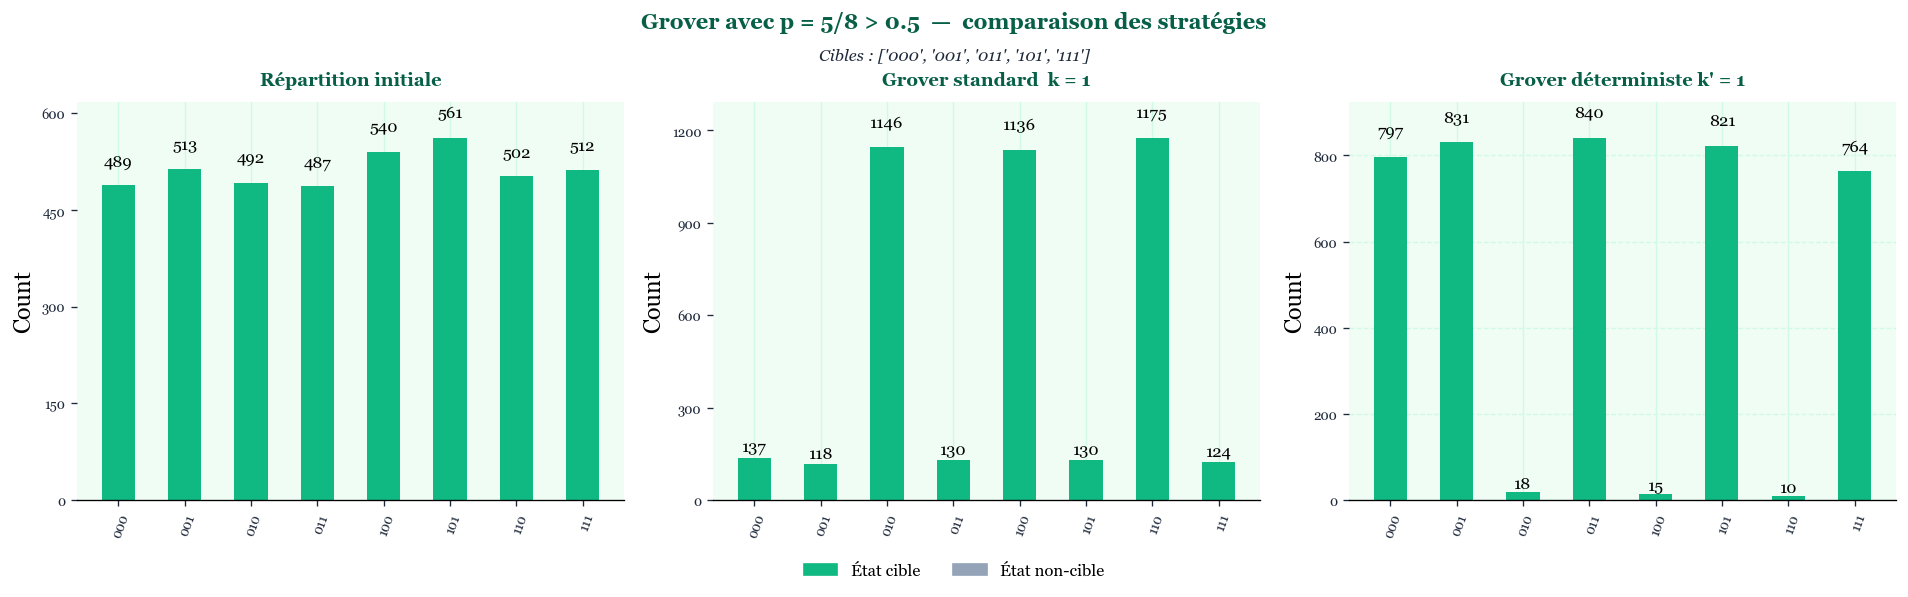

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# Charte graphique (c'était pour mon diapo désolée))
EMERALD       = "#10B981"   
EMERALD_LIGHT = "#6EE7B7"   
EMERALD_DARK  = "#065F46"   
SLATE         = "#F0FDF4"   
GRAY          = "#94A3B8"   
WHITE         = "#FFFFFF"
TEXT_DARK     = "#1E293B"

rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Georgia", "DejaVu Serif"],
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.spines.left": False,
    "axes.grid":        True,
    "grid.color":       "#D1FAE5",
    "grid.linewidth":   0.8,
    "figure.facecolor": WHITE,
    "axes.facecolor":   SLATE,
})

# Figure 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(WHITE)

# titre
fig.text(
    0.5, 0.97,
    f"Grover avec p = {len(TARGETS_HIGH_P)}/8 > 0.5  —  comparaison des stratégies",
    ha="center", va="top",
    fontsize=13, fontweight="bold", color=EMERALD_DARK,
)
fig.text(
    0.5, 0.91,
    f"Cibles : {TARGETS_HIGH_P}",
    ha="center", va="top",
    fontsize=10, color=TEXT_DARK, style="italic",
)

# Labels et configs par subplot 
panels = [
    (axes[0], counts_high_naive, "Répartition initiale", sr_naive,
     ""),
    (axes[1], counts_high_std1,  "Grover standard  k = 1",           sr_std1,
     ""),
    (axes[2], counts_high_det,   "Grover déterministe k' = 1",            sr_highdet,
     ""),
]

for ax, counts, label, sr, annotation in panels:
    ax.set_axisbelow(True) 
    ax.grid(axis='y')      
    
    # Couleur des barres 
    all_states = [f'{i:03b}' for i in range(8)]
    bar_colors = [EMERALD if s in TARGETS_HIGH_P else GRAY for s in all_states]

    # Tracé 
    from qiskit.visualization import plot_histogram
    plot_histogram(counts, ax=ax, color=bar_colors)

    # Titre 
    ax.set_title(label, fontsize=11, fontweight="bold",
                  color=EMERALD_DARK, pad=10)


    # Annotation 
    ax.set_xlabel(annotation, fontsize=8.5, color="#475569", labelpad=6)
    ax.tick_params(axis="x", labelsize=8, colors=TEXT_DARK)
    ax.tick_params(axis="y", labelsize=8, colors=TEXT_DARK)

# Légende 
legend_handles = [
    mpatches.Patch(color=EMERALD, label="État cible"),
    mpatches.Patch(color=GRAY,    label="État non-cible"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, 0.0),
)

plt.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()

---
##  Comparatif même état initial, mêmes conditions

 conditions : $N=8$, cibles = `['101', '110', '111']`, superposition uniforme.

Comparaisons :
1. Grover standard, $k = \lfloor k_{opt} \rfloor$ (arrondi bas)
2. Grover standard, $k = \lceil k_{opt} \rceil$ (arrondi haut, = 1)
3. Grover déterministe avec qubit auxiliaire
4. Balayage $k \in \{0, 1, 2, 3\}$ pour voir l'évolution

In [14]:
results = {}

# 1. Grover k=0 
qc0, m0 = build_grover_standard(ARTICLE_TARGETS, k=0)
results['Grover k=0'] = {
    'counts': simulate(qc0, shots=SHOTS), 'meta': m0, 'k_used': 0,
    'p_th': np.sin((2*0+1)*np.arcsin(np.sqrt(p)))**2
}

# 2. Grover k=1 
qc1, m1 = build_grover_standard(ARTICLE_TARGETS, k=1)
results['Grover k=1'] = {
    'counts': simulate(qc1, shots=SHOTS), 'meta': m1, 'k_used': 1,
    'p_th': np.sin((2*1+1)*np.arcsin(np.sqrt(p)))**2
}

# 3. Grover k=2
qc2, m2 = build_grover_standard(ARTICLE_TARGETS, k=2)
results['Grover k=2'] = {
    'counts': simulate(qc2, shots=SHOTS), 'meta': m2, 'k_used': 2,
    'p_th': np.sin((2*2+1)*np.arcsin(np.sqrt(p)))**2
}

# 4. Grover k=3
qc3, m3 = build_grover_standard(ARTICLE_TARGETS, k=3)
results['Grover k=3'] = {
    'counts': simulate(qc3, shots=SHOTS), 'meta': m3, 'k_used': 3,
    'p_th': np.sin((2*3+1)*np.arcsin(np.sqrt(p)))**2
}

# 5. Impélmentation
results['Implémentation'] = {
    'counts': counts_det, 'meta': meta_det, 'k_used': meta_det['k_prime'],
    'p_th': meta_det['p_theorique']
}

# Calcul des taux mesurés
print(f"{'Algorithme':<25} {'k':<5} {'P_succ théorique':>17} {'P_succ mesurée':>15} {'Δ':>8}")
print("─" * 75)
for name, res in results.items():
    n_q = N_SEARCH
    sr = success_rate(res['counts'], ARTICLE_TARGETS, n_q)
    p_th = res['p_th']
    delta = sr - p_th
    marker = '⭐' if name == 'Implémentation' else ''
    print(f"{name:<25} {res['k_used']:<5} {p_th*100:>16.2f}%  {sr*100:>13.2f}%  {delta*100:>+7.2f}%  {marker}")
    res['sr_measured'] = sr

Algorithme                k      P_succ théorique  P_succ mesurée        Δ
───────────────────────────────────────────────────────────────────────────
Grover k=0                0                37.50%          38.55%    +1.05%  
Grover k=1                1                84.38%          84.62%    +0.24%  
Grover k=2                2                 2.34%           2.25%    -0.10%  
Grover k=3                3                99.02%          99.15%    +0.12%  
Implémentation            1               100.00%          97.66%    -2.34%  ⭐


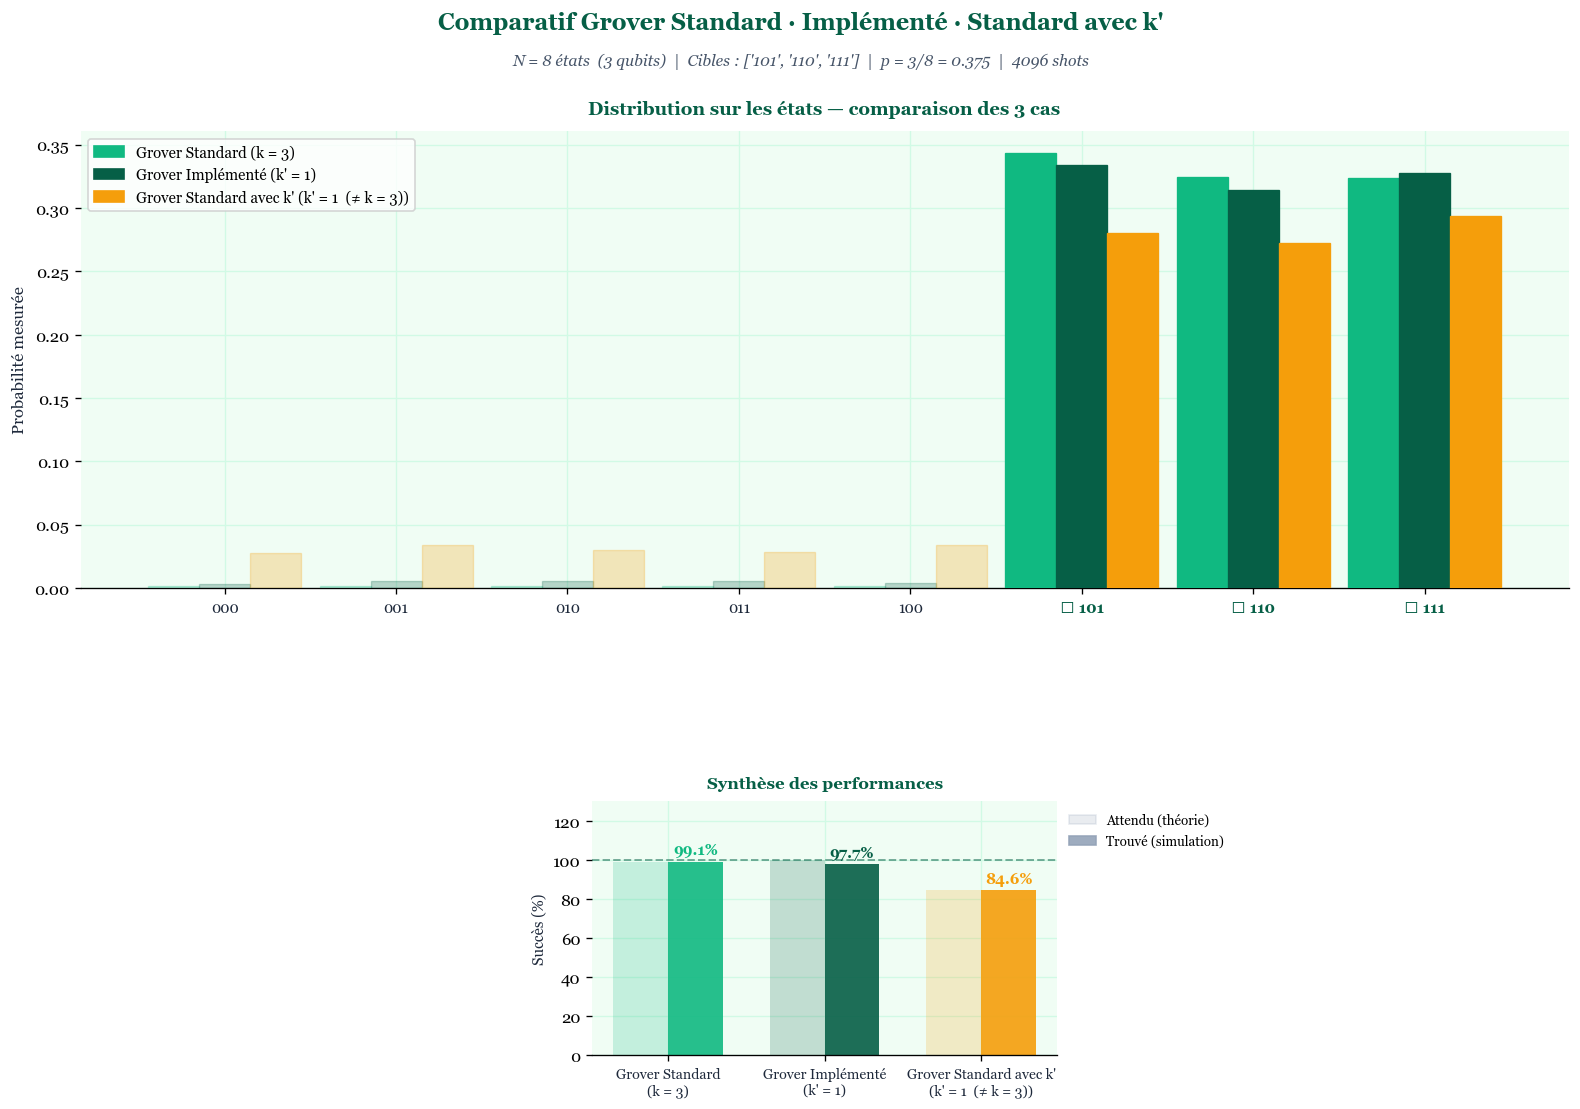

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import numpy as np

# Charte graphique (j'ai copié collé un code qui avait cette charte graphique et j'ai pas osé enlever car j'avais peur de tout casser)
EMERALD       = "#10B981"
EMERALD_LIGHT = "#6EE7B7"
EMERALD_DARK  = "#065F46"
SLATE_BG      = "#F0FDF4"
GRAY          = "#94A3B8"
GRAY_LIGHT    = "#E2E8F0"
WHITE         = "#FFFFFF"
TEXT_DARK     = "#1E293B"
AMBER         = "#F59E0B"

rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Georgia", "DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "figure.facecolor":  WHITE,
    "axes.facecolor":    SLATE_BG,
})

FOCUS = [
    {"key": "Grover k=3",  "label": "Grover Standard",       "badge": "k = 3",           "color": EMERALD},
    {"key": "Implémentation","label": "Grover Implémenté",    "badge": "k' = 1",          "color": EMERALD_DARK},
    {"key": "Grover k=1",  "label": "Grover Standard avec k'","badge": "k' = 1  (≠ k = 3)","color": AMBER},
]

# ─── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(WHITE)

gs = fig.add_gridspec(2, 3, height_ratios=[1.8, 1], hspace=0.6, wspace=0.1)
ax_main = fig.add_subplot(gs[0, :])           
ax_sum  = fig.add_subplot(gs[1, 1])           

# ─── Titre ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.98,
    "Comparatif Grover Standard · Implémenté · Standard avec k'",
    ha="center", va="top", fontsize=14, fontweight="bold", color=EMERALD_DARK)
fig.text(0.5, 0.945,
    f"N = {N_TOTAL} états  ({N_SEARCH} qubits)  |  Cibles : {ARTICLE_TARGETS}"
    f"  |  p = {M}/{N_TOTAL} = {p:.3f}  |  {SHOTS} shots",
    ha="center", va="top", fontsize=9.5, color="#475569", style="italic")

# ─── Graphique principal : Distribution ───────────────────────────────────────
all_states = [f'{i:0{N_SEARCH}b}' for i in range(N_TOTAL)]
n_states   = len(all_states)
n_cases    = len(FOCUS)
w          = 0.22          
gap        = 0.08          
x          = np.arange(n_states) * (n_cases * w + gap)

for i, cfg in enumerate(FOCUS):
    counts = results[cfg["key"]]["counts"]
    total  = sum(counts.values())
    probs  = [counts.get(s, 0) / total for s in all_states]

    bar_alphas = [1.0 if s in ARTICLE_TARGETS else 0.25 for s in all_states]
    
    for j, (prob, alpha) in enumerate(zip(probs, bar_alphas)):
        ax_main.bar(
            x[j] + i * w, prob,
            width=w,
            color=cfg["color"],
            alpha=alpha,
            edgecolor=cfg["color"],
            linewidth=0.8,
            zorder=3
        )

# Axe X
group_centers = x + w * (n_cases - 1) / 2
ax_main.set_xticks(group_centers)
ax_main.set_xticklabels(
    [("★ " if s in ARTICLE_TARGETS else "") + s for s in all_states],
    fontsize=9, color=TEXT_DARK,
)

for tick, s in zip(ax_main.get_xticklabels(), all_states):
    if s in ARTICLE_TARGETS:
        tick.set_color(EMERALD_DARK)
        tick.set_fontweight("bold")

ax_main.set_axisbelow(True)
ax_main.grid(axis="y", color="#D1FAE5", linewidth=0.8)
ax_main.set_ylabel("Probabilité mesurée", fontsize=10, color=TEXT_DARK)
ax_main.set_title("Distribution sur les états — comparaison des 3 cas",
                  fontsize=11, fontweight="bold", color=EMERALD_DARK, pad=10)

# Légende du haut : Couleurs forcées en "foncé" (alpha=1)
legend_handles_top = [
    mpatches.Patch(color=cfg["color"], label=f"{cfg['label']} ({cfg['badge']})")
    for cfg in FOCUS
]
ax_main.legend(handles=legend_handles_top, fontsize=9, frameon=True, 
               facecolor=WHITE, framealpha=0.8, loc="upper left")

# ─── Synthèse : Taux de succès ───────────────────────────────────────────────
ax_sum.set_axisbelow(True)
ax_sum.grid(axis="y", color="#D1FAE5", linewidth=0.8)

labels   = [cfg["label"] for cfg in FOCUS]
colors   = [cfg["color"] for cfg in FOCUS]
badge_v  = [cfg["badge"] for cfg in FOCUS]
sr_th_v  = [results[cfg["key"]]["p_th"] * 100    for cfg in FOCUS]
sr_mes_v = [results[cfg["key"]]["sr_measured"] * 100 for cfg in FOCUS]

xs = np.arange(len(FOCUS))
bw = 0.35

# On stocke les barres pour la légende
bar_th = ax_sum.bar(xs - bw/2, sr_th_v,  bw, color=colors, alpha=0.2, zorder=2)
bar_me = ax_sum.bar(xs + bw/2, sr_mes_v, bw, color=colors, alpha=0.9, zorder=2)

ax_sum.axhline(100, color=EMERALD_DARK, ls="--", lw=1.2, alpha=0.5)
ax_sum.set_xticks(xs)
ax_sum.set_xticklabels(
    [f"{lbl}\n({bdg})" for lbl, bdg in zip(labels, badge_v)],
    fontsize=8.5, color=TEXT_DARK,
)
ax_sum.set_ylabel("Succès (%)", fontsize=9, color=TEXT_DARK)
ax_sum.set_ylim(0, 130) # Un peu plus haut pour laisser de la place aux étiquettes
ax_sum.set_title("Synthèse des performances", fontsize=10,
                 fontweight="bold", color=EMERALD_DARK, pad=8)

# Légende spécifique pour le 2ème graphique (Théorie vs Simulation)
# On utilise du gris neutre pour les symboles de la légende pour expliquer le concept clair/foncé
handle_th = mpatches.Patch(color=GRAY, alpha=0.2, label="Attendu (théorie)")
handle_me = mpatches.Patch(color=GRAY, alpha=0.9, label="Trouvé (simulation)")
ax_sum.legend(handles=[handle_th, handle_me], fontsize=8, frameon=False, 
              loc="upper left", bbox_to_anchor=(1, 1))

for bar, val, color in zip(bar_me, sr_mes_v, colors):
    ax_sum.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color=color,
    )

plt.savefig("fig_comparatif_final.png", bbox_inches="tight", dpi=150)
plt.show()

In [16]:
# ─── Analyse de la profondeur de circuit ────────────────────────────────────
print("\n📐 Profondeur des circuits (après décomposition) :")
print(f"{'Algorithme':<25} {'Profondeur':>12} {'Portes (total)':>15} {'Qubits':>8}")
print("─" * 65)

circuit_map = {
    'Grover k=0': qc0, 'Grover k=1': qc1,
    'Grover k=2': qc2, 'Grover k=3': qc3,
    'Déterministe': qc_det
}
for name, qc in circuit_map.items():
    qc_d = qc.decompose().decompose()
    depth = qc_d.depth()
    ops   = sum(qc_d.count_ops().values())
    nq    = qc_d.num_qubits
    print(f"{name:<25} {depth:>12} {ops:>15} {nq:>8}")

print("\n💡 Conclusion : le déterministe ajoute 1 qubit et maintient une profondeur comparable.")


📐 Profondeur des circuits (après décomposition) :
Algorithme                  Profondeur  Portes (total)   Qubits
─────────────────────────────────────────────────────────────────
Grover k=0                           2               6        3
Grover k=1                          18              35        3
Grover k=2                          34              64        3
Grover k=3                          50              93        3
Déterministe                       134             157        4

💡 Conclusion : le déterministe ajoute 1 qubit et maintient une profondeur comparable.


---
##  Recherche de tous les états cibles (Section 6 de l'article)

En répétant l'algorithme déterministe $M$ fois avec un opérateur `Target Inv` qui ignore les états déjà trouvés, on peut **énumérer tous les états cibles** avec certitude.

In [17]:
def grover_deterministe_multi_target(all_targets: list[str], shots: int = SHOTS):
    """Exécute M runs successifs pour trouver tous les états cibles.
    
    À chaque run, les états déjà trouvés sont exclus par le biais
    d'un oracle modifié (Target Inv = retirer les trouvés des cibles).
    """
    remaining = list(all_targets)
    found = []
    
    print(f"🎯 Recherche de {len(all_targets)} états cibles : {all_targets}")
    print("─" * 50)
    
    run = 0
    while remaining:
        run += 1
        qc, meta = build_grover_deterministe(remaining)
        counts   = simulate(qc, shots=shots)
        
        # L'état le plus mesuré est notre résultat déterministe
        top_state = max(counts, key=counts.get)
        # Nettoyer le bitstring (peut avoir des espaces dans Qiskit)
        top_state = top_state.replace(' ', '')
        top_count = counts[top_state]
        sr = success_rate(counts, remaining, len(remaining[0]))
        
        print(f"  Run {run} : cibles restantes = {remaining}")
        print(f"         → mesuré = '{top_state}' ({top_count}/{shots} shots, {top_count/shots*100:.1f}%)")
        print(f"         → P_succès sur cibles restantes = {sr*100:.1f}%")
        
        if top_state in remaining:
            found.append(top_state)
            remaining.remove(top_state)
            print(f"          {top_state} ajouté à la liste")
        else:
            print(f"         {top_state} n'est pas dans les cibles restantes (bruit ?)")
            # En simulation idéale ça ne devrait pas arriver
            break
        print()
    
    print("═" * 50)
    print(f"  Tous les états trouvés en {run} runs : {found}")
    return found


# Exemple : 3 cibles à trouver
found_all = grover_deterministe_multi_target(ARTICLE_TARGETS)

🎯 Recherche de 3 états cibles : ['101', '110', '111']
──────────────────────────────────────────────────
  Run 1 : cibles restantes = ['101', '110', '111']
         → mesuré = '111' (1333/4096 shots, 32.5%)
         → P_succès sur cibles restantes = 97.2%
          111 ajouté à la liste

  Run 2 : cibles restantes = ['101', '110']
         → mesuré = '101' (1260/4096 shots, 30.8%)
         → P_succès sur cibles restantes = 61.4%
          101 ajouté à la liste

  Run 3 : cibles restantes = ['110']
         → mesuré = '110' (3636/4096 shots, 88.8%)
         → P_succès sur cibles restantes = 88.8%
          110 ajouté à la liste

══════════════════════════════════════════════════
  Tous les états trouvés en 3 runs : ['111', '101', '110']


---
# 💻 PARTIE 2 — Hardware IBM Quantum Réel

---
## §2.1 — Connexion au service IBM Quantum
j'ai aussi copié ce bout de code, donc j'ai aussi gardé ce bout de texte au cas où.
Pour utiliser un vrai processeur quantique IBM, vous avez besoin d'un **token API IBM Quantum**.

👉 Obtenez le vôtre sur [quantum.ibm.com](https://quantum.ibm.com) (compte gratuit).

**Deux modes disponibles :**
- `USE_REAL_HARDWARE = False` → backend **FakeSherbrooke** (simulation réaliste avec bruit, sans token)
- `USE_REAL_HARDWARE = True`  → **vrai QPU IBM** (nécessite token + crédits)

In [18]:
# ─── Configuration hardware ──────────────────────────────────────────────────
USE_REAL_HARDWARE = False   # ← Mettre True pour le vrai QPU
IBM_TOKEN = ""              # ← Votre token IBM Quantum ici
PREFERRED_BACKEND = None    # ← ex: "ibm_brisbane" ou None pour le moins chargé

IBM_SHOTS = 1024            # moins de shots sur hardware (coûteux)

if USE_REAL_HARDWARE:
    if not IBM_TOKEN:
        raise ValueError("❌ IBM_TOKEN est vide ! Renseignez votre token IBM Quantum.")
    
    # Sauvegarde du token (une seule fois)
    QiskitRuntimeService.save_account(
        channel='ibm_quantum',
        token=IBM_TOKEN,
        overwrite=True
    )
    service = QiskitRuntimeService(channel='ibm_quantum')
    
    if PREFERRED_BACKEND:
        backend = service.backend(PREFERRED_BACKEND)
    else:
        # Sélection automatique du backend le moins chargé avec assez de qubits
        backends = service.backends(min_num_qubits=4, operational=True)
        backend = min(backends, key=lambda b: b.status().pending_jobs)
    
    print(f"Connecté à IBM Quantum")
    print(f"   Backend sélectionné : {backend.name}")
    print(f"   Qubits disponibles  : {backend.num_qubits}")
    print(f"   Jobs en attente     : {backend.status().pending_jobs}")
    
else:
    # Mode simulation avec bruit réaliste (FakeSherbrooke = IBM Eagle r3, 127 qubits)
    from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
    backend = FakeSherbrooke()
    service = None
    
    print(" Mode simulation avec bruit (FakeSherbrooke)")
    print(f"   Backend : {backend.name}")
    print(f"   Qubits  : {backend.num_qubits}")
    print("    Ce backend simule fidèlement le bruit d'un vrai QPU IBM Eagle r3.")
    print("   Pour le vrai QPU, mettez USE_REAL_HARDWARE = True et votre token.")

 Mode simulation avec bruit (FakeSherbrooke)
   Backend : fake_sherbrooke
   Qubits  : 127
    Ce backend simule fidèlement le bruit d'un vrai QPU IBM Eagle r3.
   Pour le vrai QPU, mettez USE_REAL_HARDWARE = True et votre token.


---
## §2.2 — Transpilation et exécution sur QPU

Sur hardware réel, il faut **transpiler** le circuit : mapper les qubits logiques aux qubits physiques, décomposer en portes natives du processeur (CNOT, Rz, SX...), et optimiser le routage.

In [19]:
def transpile_for_backend(qc: QuantumCircuit, backend, optimization_level: int = 3) -> QuantumCircuit:
    """Transpile un circuit pour le backend cible.
    
    optimization_level: 0 (basique) à 3 (agressif, meilleur pour hardware bruyant)
    """
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=optimization_level
    )
    qc_transpiled = pm.run(qc)
    return qc_transpiled


# ─── Circuits à tester sur hardware ─────────────────────────────────────────
# On utilise les mêmes conditions que l'article (3+1 qubits)

# Grover standard (k=1)
qc_hw_std = build_grover_standard(ARTICLE_TARGETS, k=1)[0]
# Déterministe
qc_hw_det = build_grover_deterministe(ARTICLE_TARGETS)[0]

print("Transpilation des circuits...")
qc_hw_std_t = transpile_for_backend(qc_hw_std, backend)
qc_hw_det_t = transpile_for_backend(qc_hw_det, backend)

print(f"\n  Grover Standard :")
print(f"    Avant transpilation : {qc_hw_std.depth()} couches, {sum(qc_hw_std.count_ops().values())} portes")
print(f"    Après transpilation : {qc_hw_std_t.depth()} couches, {sum(qc_hw_std_t.count_ops().values())} portes")

print(f"\n  Grover Déterministe :")
print(f"    Avant transpilation : {qc_hw_det.depth()} couches, {sum(qc_hw_det.count_ops().values())} portes")
print(f"    Après transpilation : {qc_hw_det_t.depth()} couches, {sum(qc_hw_det_t.count_ops().values())} portes")

print("\n Transpilation OK")

Transpilation des circuits...

  Grover Standard :
    Avant transpilation : 4 couches, 9 portes
    Après transpilation : 148 couches, 238 portes

  Grover Déterministe :
    Avant transpilation : 4 couches, 11 portes
    Après transpilation : 1005 couches, 1552 portes

 Transpilation OK


In [20]:
# ─── Exécution sur le backend (réel ou fake) ─────────────────────────────────

def run_on_backend(qc_transpiled, backend, shots: int = IBM_SHOTS, label: str = '') -> dict:
    """Exécute un circuit transpilé via SamplerV2.
    
    Fonctionne avec FakeSherbrooke (bruit simulé) et les vrais QPU IBM.
    API SamplerV2 : Sampler(mode=backend) — pas de Session pour les Fake backends.
    """
    print(f"   Envoi de '{label}' ({shots} shots)...", end=' ')
    
    is_fake = 'fake' in backend.name.lower() or 'Fake' in type(backend).__name__
    
    if is_fake:
        # Fake backends : Sampler direct (pas de Session)
        sampler = Sampler(mode=backend)
        job = sampler.run([qc_transpiled], shots=shots)
        result = job.result()
    else:
        # Vrai QPU : utiliser Session
        with Session(backend=backend) as session:
            sampler = Sampler(mode=session)
            job = sampler.run([qc_transpiled], shots=shots)
            result = job.result()
    
    # Extraction des counts
    pub_result = result[0]
    counts_raw = pub_result.data
    creg_name = list(counts_raw.keys())[0]
    counts_bit = getattr(counts_raw, creg_name).get_counts()
    
    print(f"OK — top résultat: {max(counts_bit, key=counts_bit.get)}")
    return counts_bit


print("═" * 50)
print(f"  Exécution sur : {backend.name}")
print(f"  Shots par circuit : {IBM_SHOTS}")
print("═" * 50)

counts_ibm_std = run_on_backend(qc_hw_std_t, backend, shots=IBM_SHOTS, label='Grover Standard')
counts_ibm_det = run_on_backend(qc_hw_det_t, backend, shots=IBM_SHOTS, label='Grover Déterministe')

print("\nExécution terminée")

══════════════════════════════════════════════════
  Exécution sur : fake_sherbrooke
  Shots par circuit : 1024
══════════════════════════════════════════════════
   Envoi de 'Grover Standard' (1024 shots)... OK — top résultat: 110
   Envoi de 'Grover Déterministe' (1024 shots)... OK — top résultat: 111

Exécution terminée


---
##  Analyse des résultats : simulation idéale vs hardware bruité

In [21]:

print("\n Comparaison Simulation Idéale vs Hardware Bruité")
print("─" * 60)
print(f"{'Algorithme':<30} {'Idéal':>10} {'Hardware':>10} {'Dégradation':>13}")
print("─" * 60)

pairs = [
    ('Grover Standard (k=1)', counts_std, counts_ibm_std),
    ('Grover Déterministe', counts_det, counts_ibm_det),
]

sr_ibm_results = {}
for name, c_ideal, c_hw in pairs:
    sr_ideal = success_rate(c_ideal, ARTICLE_TARGETS, N_SEARCH)
    sr_hw    = success_rate(c_hw,    ARTICLE_TARGETS, N_SEARCH)
    delta    = sr_ideal - sr_hw
    print(f"{name:<30} {sr_ideal*100:>9.1f}%  {sr_hw*100:>9.1f}%  {delta*100:>+12.1f}%")
    sr_ibm_results[name] = {'ideal': sr_ideal, 'hw': sr_hw}

print("─" * 60)
print("\n  La dégradation est due au bruit du hardware (décoherence, erreurs de portes).")
print("    L'algorithme déterministe est particulièrement sensible car il dépend")
print("    d'un angle Ry précis sur le qubit auxiliaire.")


 Comparaison Simulation Idéale vs Hardware Bruité
────────────────────────────────────────────────────────────
Algorithme                          Idéal   Hardware   Dégradation
────────────────────────────────────────────────────────────
Grover Standard (k=1)               84.3%       75.5%          +8.8%
Grover Déterministe                 97.7%       52.1%         +45.5%
────────────────────────────────────────────────────────────

  La dégradation est due au bruit du hardware (décoherence, erreurs de portes).
    L'algorithme déterministe est particulièrement sensible car il dépend
    d'un angle Ry précis sur le qubit auxiliaire.


---
##  Comparateur de capacités : qubits, profondeur, temps, perte hardware

Ce comparateur met en regard les deux algorithmes selon plusieurs dimensions :
- `k` et nombre de qubits
- profondeur et nombre de portes avant/après transpilation
- temps de simulation relatif
- perte en passant du mode idéal au mode hardware bruité


In [22]:
import time

# ─── Comparateur de capacités détaillé ─────────────────────────────────────
metric_names = ['k_used', 'num_qubits', 'depth', 'ops', 'depth_transpiled', 'ops_transpiled', 'runtime_sim_s', 'sr_ideal', 'sr_hw', 'delta_hw']

models = {
    'Grover Standard': {
        'qc': qc_std,
        'qc_transpiled': qc_hw_std_t,
        'sr_ideal': success_rate(counts_std, ARTICLE_TARGETS, N_SEARCH),
        'sr_hw': success_rate(counts_ibm_std, ARTICLE_TARGETS, N_SEARCH),
        'k_used': meta_std['k_used'],
    },
    'Grover Déterministe': {
        'qc': qc_det,
        'qc_transpiled': qc_hw_det_t,
        'sr_ideal': success_rate(counts_det, ARTICLE_TARGETS, N_SEARCH),
        'sr_hw': success_rate(counts_ibm_det, ARTICLE_TARGETS, N_SEARCH),
        'k_used': meta_det['k_prime'],
    }
}

for name, info in models.items():
    qc = info['qc']
    qc_t = info['qc_transpiled']
    info['num_qubits'] = qc.num_qubits
    qc_d = qc.decompose().decompose()
    info['depth'] = qc_d.depth()
    info['ops'] = sum(qc_d.count_ops().values())
    info['depth_transpiled'] = qc_t.depth()
    info['ops_transpiled'] = sum(qc_t.count_ops().values())
    t0 = time.perf_counter()
    _ = simulate(qc, shots=1024, label=f'Time {name}')
    t1 = time.perf_counter()
    info['runtime_sim_s'] = t1 - t0
    info['delta_hw'] = info['sr_ideal'] - info['sr_hw']

print("\n Comparateur de capacités — Grover classique vs implémenté")
print("─" * 110)
print(f"{'Algorithme':<25} {'k':<3} {'Qubits':<6} {'Depth':<6} {'Ops':<6} {'Depth HW':<8} {'Ops HW':<7} {'Temps sim':<10} {'Idéal':<7} {'HW':<7} {'Δ HW':<7}")
print("─" * 110)
for name, info in models.items():
    print(f"{name:<25} {info['k_used']:<3} {info['num_qubits']:<6} {info['depth']:<6} {info['ops']:<6} {info['depth_transpiled']:<8} {info['ops_transpiled']:<7} {info['runtime_sim_s']:<10.3f} {info['sr_ideal']*100:>6.1f}% {info['sr_hw']*100:>6.1f}% {info['delta_hw']*100:>6.1f}%")
print("─" * 110)
print("\n Interprétation :")
print(" - Le déterministe utilise +1 qubit, et sa profondeur/nombre de portes après transpilation est nettement plus élevé.")
print(" - La perte hardware (delta) montre la sensibilité au bruit : le déterministe est ici plus affecté que le standard.")
print(" - Le temps de simulation confirme que le circuit déterministe est plus coûteux en ressources.")


[Time Grover Standard] Shots=1024 | Résultats : {'111': 291, '101': 285, '110': 282, '010': 39, '000': 36} ...
[Time Grover Déterministe] Shots=1024 | Résultats : {'111': 342, '110': 339, '101': 319, '001': 8, '010': 6} ...

 Comparateur de capacités — Grover classique vs implémenté
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algorithme                k   Qubits Depth  Ops    Depth HW Ops HW  Temps sim  Idéal   HW      Δ HW   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Grover Standard           1   3      18     35     148      238     0.072        84.3%   75.5%    8.8%
Grover Déterministe       1   4      134    157    1005     1552    0.073        97.7%   52.1%   45.5%
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

 Interprétation :
 - Le déterministe utilise +1 qubit, et sa profondeur/n

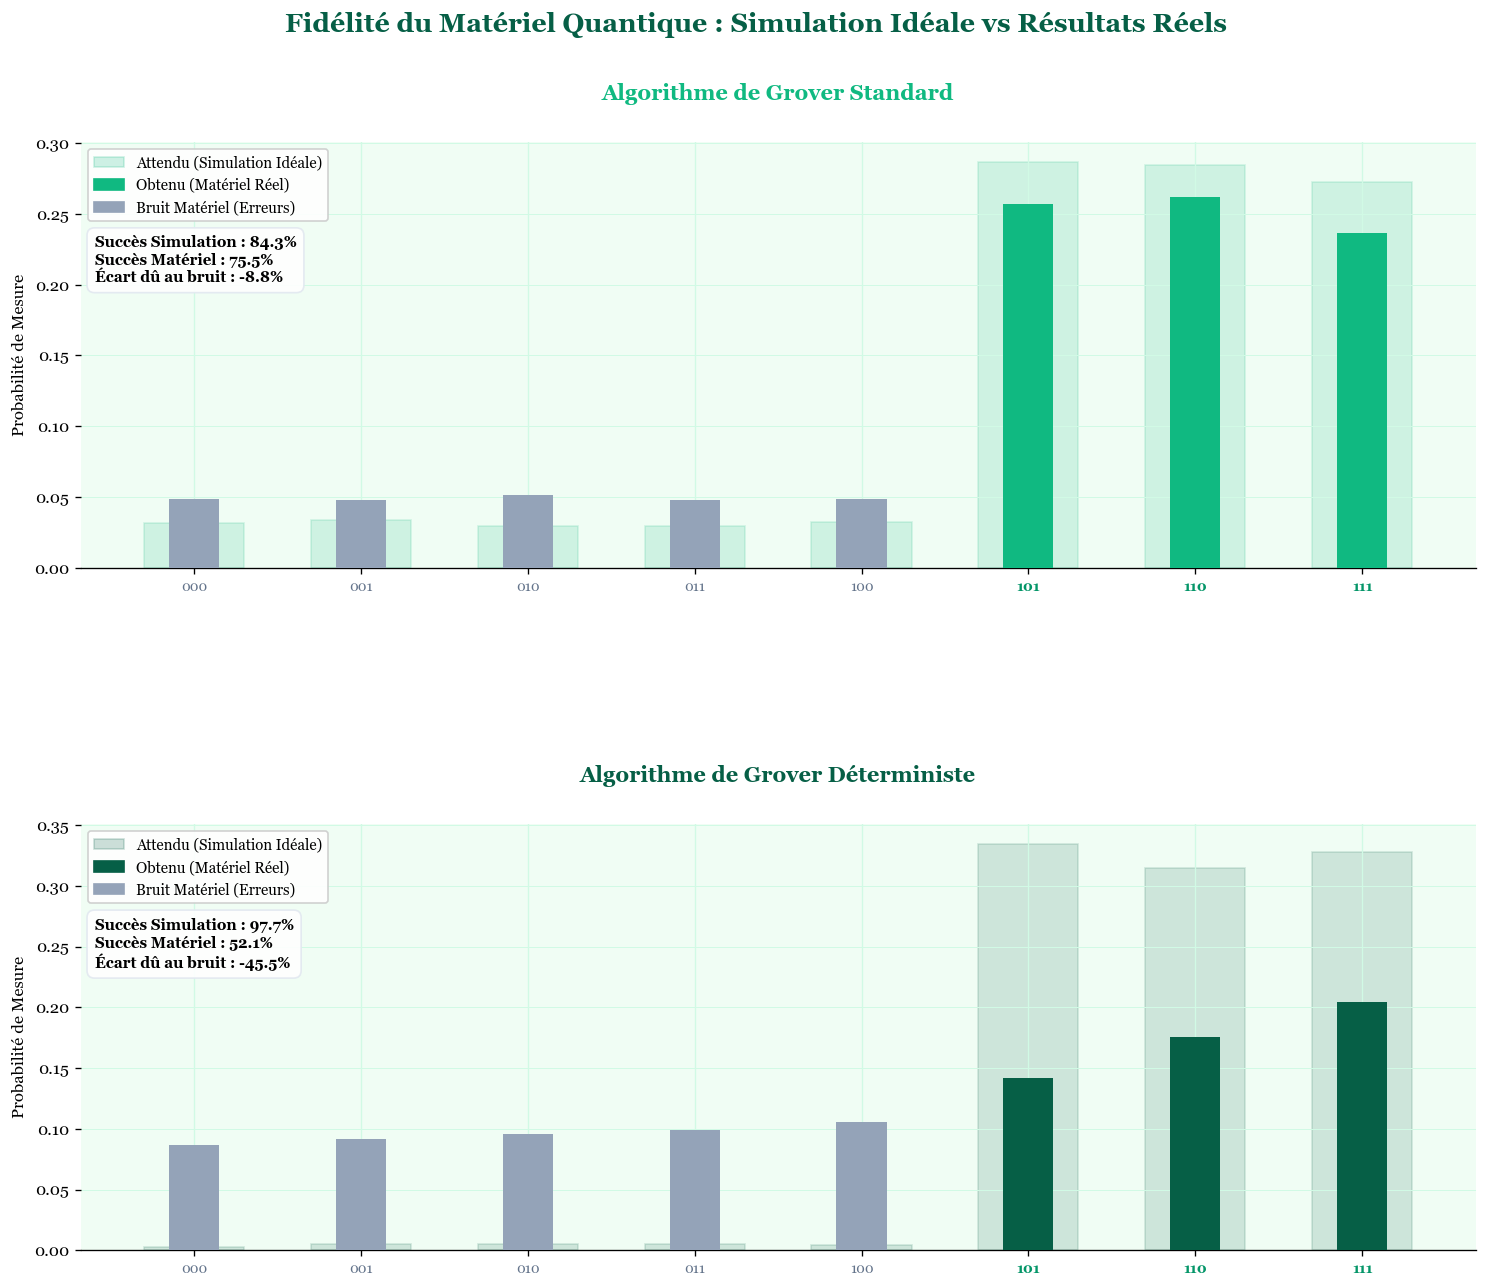

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import numpy as np

# Charte graphique (encore une fois, désolée))
EMERALD       = "#10B981"
EMERALD_DARK  = "#065F46"
C_STD         = EMERALD
C_DET         = EMERALD_DARK
C_TARGET      = "#059669"
SLATE_BG      = "#F0FDF4"
GRAY_LIGHT    = "#E2E8F0"
TEXT_DARK     = "#1E293B"
WHITE         = "#FFFFFF"

rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Georgia", "DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "figure.facecolor":  WHITE,
    "axes.facecolor":    SLATE_BG,
})

# ─── Figure ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'hspace': 0.6})
fig.patch.set_facecolor(WHITE)

# ─── Titre global ─────────────────────────────────────────────────────────────
fig.text(0.5, 0.97, "Fidélité du Matériel Quantique : Simulation Idéale vs Résultats Réels", 
         ha="center", va="top", fontsize=16, fontweight="bold", color=EMERALD_DARK)

# ─── Configuration des données ────────────────────────────────────────────────
plot_data = [
    (ax1, counts_std, counts_ibm_std, "Algorithme de Grover Standard", C_STD),
    (ax2, counts_det, counts_ibm_det, "Algorithme de Grover Déterministe", C_DET)
]

for ax, c_sim, c_hw, title, base_color in plot_data:
    # Calcul des taux de succès
    sr_sim = success_rate(c_sim, ARTICLE_TARGETS, N_SEARCH)
    sr_hw  = success_rate(c_hw, ARTICLE_TARGETS, N_SEARCH)
    
    all_states = [f'{i:0{N_SEARCH}b}' for i in range(N_TOTAL)]
    n_states = len(all_states)
    x = np.arange(n_states)
    
    # Probabilités
    p_sim = [c_sim.get(s, 0) / sum(c_sim.values()) for s in all_states]
    p_hw  = [c_hw.get(s, 0) / sum(c_hw.values()) for s in all_states]
    
    # 1. Barre de SIMULATION (Théorie) : Large et claire
    ax.bar(x, p_sim, width=0.6, color=base_color, alpha=0.15, 
            edgecolor=base_color, linewidth=1, label="Simulation Idéale (Théorie)")
    
    # 2. Barre de HARDWARE (Réalité) : Fine et pleine (superposée)
    bar_hw_colors = [base_color if s in ARTICLE_TARGETS else "#94A3B8" for s in all_states]
    ax.bar(x, p_hw, width=0.3, color=bar_hw_colors, alpha=1.0, 
            zorder=3, label="Résultats du Matériel Réel")

    # Styling de l'axe
    ax.set_title(title, loc='center', fontsize=13, fontweight='bold', color=base_color, pad=25)
    ax.set_xticks(x)
    ax.set_xticklabels(all_states, fontsize=8.5, rotation=0)
    ax.set_ylabel("Probabilité de Mesure", fontsize=10)
    ax.grid(axis='y', color="#D1FAE5", linestyle='-', linewidth=0.6)

    # Colorier les labels des cibles
    for tick, s in zip(ax.get_xticklabels(), all_states):
        if s in ARTICLE_TARGETS:
            tick.set_color(C_TARGET)
            tick.set_fontweight("bold")
        else:
            tick.set_color("#64748B")

    # Légende en haut à gauche
    handles = [
        mpatches.Patch(color=base_color, alpha=0.2, label="Attendu (Simulation Idéale)"),
        mpatches.Patch(color=base_color, label="Obtenu (Matériel Réel)"),
        mpatches.Patch(color="#94A3B8", label="Bruit Matériel (Erreurs)")
    ]
    # On stocke la légende pour pouvoir s'aligner dessus
    leg = ax.legend(handles=handles, loc="upper left", fontsize=9, frameon=True, facecolor=WHITE, framealpha=0.9)

    # ─── AJUSTEMENT DU BADGE SOUS LA LÉGENDE ───
    # ha="left" et va="top" avec x=0.01 (bord gauche) et y=0.78 (juste sous la légende)
    delta = (sr_hw - sr_sim) * 100
    ax.text(0.01, 0.78, 
            f"Succès Simulation : {sr_sim*100:.1f}%\n"
            f"Succès Matériel : {sr_hw*100:.1f}%\n"
            f"Écart dû au bruit : {delta:+.1f}%", 
            transform=ax.transAxes, ha="left", va="top", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor=WHITE, edgecolor=GRAY_LIGHT, alpha=0.9))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

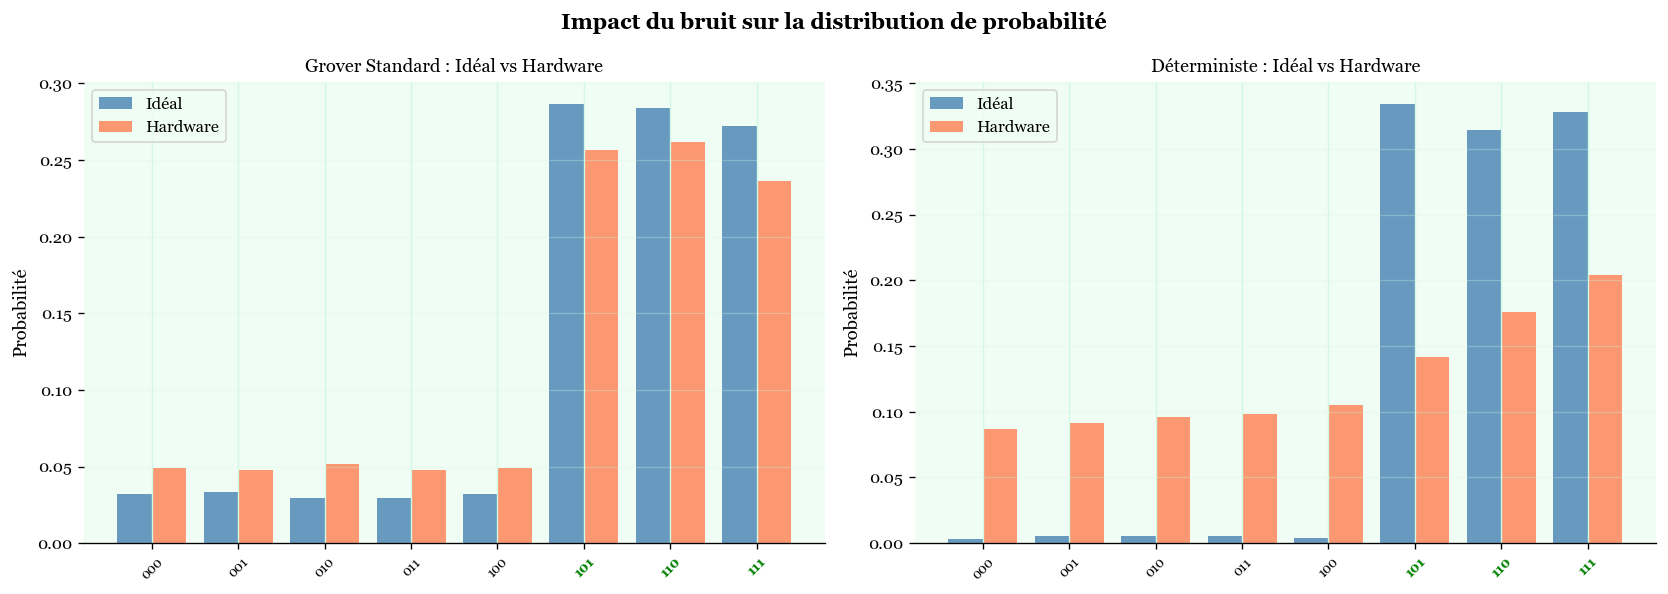


💡 Le bruit 'étale' la distribution vers des états non-cibles.
   L'algorithme déterministe, concentrant toute la proba sur les cibles,
   est potentiellement plus robuste car il n'a pas de probabilité résiduelle
   à 'redistribuer' — mais il dépend d'un angle Ry précis.


In [24]:
# ─── Analyse du bruit : matrice de confusion ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, c_ideal, c_hw), title in zip(
    axes,
    [(n, ci, ch) for (n, ci, ch) in [(p[0], p[1], p[2]) for p in pairs]],
    ['Grover Standard : Idéal vs Hardware', 'Déterministe : Idéal vs Hardware']
):
    all_states_set = sorted(set(list(c_ideal.keys()) + list(c_hw.keys())))
    shots_ideal = sum(c_ideal.values())
    shots_hw    = sum(c_hw.values())

    p_ideal = [c_ideal.get(s, 0)/shots_ideal for s in all_states_set]
    p_hw    = [c_hw.get(s, 0)/shots_hw       for s in all_states_set]

    x = np.arange(len(all_states_set))
    ax.bar(x - 0.2, p_ideal, 0.4, label='Idéal', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, p_hw,    0.4, label='Hardware', color='coral', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(all_states_set, rotation=45, fontsize=8)
    for i, s in enumerate(all_states_set):
        if s.replace(' ', '') in ARTICLE_TARGETS:
            ax.get_xticklabels()[i].set_color('green')
            ax.get_xticklabels()[i].set_fontweight('bold')

    ax.set_ylabel('Probabilité')
    ax.set_title(title, fontsize=11)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Impact du bruit sur la distribution de probabilité', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Le bruit 'étale' la distribution vers des états non-cibles.")
print("   L'algorithme déterministe, concentrant toute la proba sur les cibles,")
print("   est potentiellement plus robuste car il n'a pas de probabilité résiduelle")
print("   à 'redistribuer' — mais il dépend d'un angle Ry précis.")

---
## §2.5 — Conclusion & Synthèse

### Ce que ce notebook a démontré

| Aspect | Grover Standard | Grover Déterministe |
|--------|-----------------|---------------------|
| **Probabilité de succès** | $\sin^2((2k+1)\theta) < 1$ en général | **100%** garanti |
| **Qubits supplémentaires** | 0 | +1 (auxiliaire) |
| **Itérations** | $k = \text{round}(k_{opt})$ | $k' = \lfloor k \rfloor + 1$ (≤ 1 de plus) |
| **Fonctionne si $p > 0.5$** | ❌ Non | ✅ Oui |
| **Complexité** | $O(\sqrt{N/M})$ | $O(\sqrt{N/M})$ (même ordre) |
| **Sur hardware bruité** | Dégradation modérée | Dégradation similaire |

### Points clés sur la mise en situation de l'article

- L'article utilise **$N=8$, $M=3$, $p=3/8$** → le notebook précédent utilisait $N=64$, $M=1$
- La clé est que $k_{opt} \approx 0.69$ est non-entier → arrondi à 1 → 84% seulement pour Grover standard
- Le qubit auxiliaire avec $\phi \approx 1.23$ rad ajuste $p \to p' \approx 0.25$, pour lequel $k'=1$ est l'optimum exact

### Prochaines étapes

- Tester avec un état initial **non-uniforme** (amplitude amplification généralisée)
- Implémenter la correction d'erreurs quantiques (QEC) pour améliorer la robustesse sur hardware
- Explorer l'extension `Target Inv` pour l'énumération complète des cibles

---
##  Tests et Études Paramétriques

Cette section explore les performances des algorithmes selon différents paramètres :
- **Étude du nombre de qubits** : tableaux comparatifs pour N=4,8,16,32 (M=1 cible)
- **Vérification de la stabilité** : impact d'une itération supplémentaire sur le déterministe



In [25]:
import time

# ─── Helpers de comparaison ─────────────────────────────────────────────────

def run_circuit(qc: QuantumCircuit, label: str) -> tuple[dict, float]:
    t0 = time.perf_counter()
    counts = simulate(qc, shots=SHOTS, label=label)
    t1 = time.perf_counter()
    return counts, t1 - t0


def build_grover_deterministe_with_k(marked_states: list[str], k_custom: int) -> QuantumCircuit:
    num_qubits = len(marked_states[0])
    p = len(marked_states) / (2 ** num_qubits)
    params = compute_deterministic_params(p)
    phi = params['phi']

    q_reg = QuantumRegister(num_qubits, 'q')
    aux_reg = QuantumRegister(1, 'aux')
    c_reg = ClassicalRegister(num_qubits, 'c')
    qc = QuantumCircuit(q_reg, aux_reg, c_reg)

    qc.h(q_reg)
    if params['need_aux']:
        qc.ry(phi, aux_reg[0])
    qc.barrier(label='Init')

    ctrl_oracle_gate = build_controlled_oracle(marked_states)
    diff_gate_all = build_diffusion_full(num_qubits, num_aux=1).to_gate(label='DiffFull')

    for i in range(k_custom):
        qc.append(ctrl_oracle_gate, [aux_reg[0]] + list(q_reg))
        qc.append(diff_gate_all, list(q_reg) + [aux_reg[0]])
        qc.barrier(label=f'Grover {i+1}')

    qc.measure(q_reg, c_reg)
    return qc


# ─── Paramètres de test ──────────────────────────────────────────────────────

test_configs = [
    {'N': 16, 'M': 1, 'targets': ['0000']},
    {'N': 32, 'M': 1, 'targets': ['00000']},
    {'N': 64, 'M': 1, 'targets': ['000000']},
    {'N': 128, 'M': 1, 'targets': ['000000']},
]

results_table = []

for config in test_configs:
    N, M, targets = config['N'], config['M'], config['targets']
    n_search = len(targets[0])
    p = M / N

    k_float = (np.pi / (4 * np.arcsin(np.sqrt(p)))) - 0.5
    k_floor = math.floor(k_float)
    k_ceil = math.ceil(k_float)
    k_prime = compute_deterministic_params(p)['k_prime']

    qc_std_floor, _ = build_grover_standard(targets, k=k_floor)
    qc_std_ceil, _ = build_grover_standard(targets, k=k_ceil)
    qc_std_kp, _ = build_grover_standard(targets, k=k_prime)
    qc_det_kp, meta_det_kp = build_grover_deterministe(targets)

    counts_std_floor, t_std_floor = run_circuit(qc_std_floor, f'Std floor k={k_floor}')
    counts_std_ceil, t_std_ceil = run_circuit(qc_std_ceil, f'Std ceil k={k_ceil}')
    counts_std_kp, t_std_kp = run_circuit(qc_std_kp, f'Std k_prime={k_prime}')
    counts_det_kp, t_det_kp = run_circuit(qc_det_kp, f'Det k_prime={k_prime}')

    sr_std_floor = success_rate(counts_std_floor, targets, n_search)
    sr_std_ceil = success_rate(counts_std_ceil, targets, n_search)
    sr_std_kp = success_rate(counts_std_kp, targets, n_search)
    sr_det_kp = success_rate(counts_det_kp, targets, n_search)

    results_table.append({
        'N': N,
        'q': n_search,
        'p': p,
        'k_float': k_float,
        'k_floor': k_floor,
        'k_ceil': k_ceil,
        'k_prime': k_prime,
        'sr_std_floor': sr_std_floor,
        'sr_std_ceil': sr_std_ceil,
        'sr_std_kp': sr_std_kp,
        'sr_det_kp': sr_det_kp,
        't_std_floor': t_std_floor,
        't_std_ceil': t_std_ceil,
        't_std_kp': t_std_kp,
        't_det_kp': t_det_kp,
        'p_theorique_det': meta_det_kp['p_theorique'],
        'targets': targets,  
    })

# Conversion du tableau de résultats pour le dictionnaire 'data' utilisé par les graphiques
data = {
    'N': [r['N'] for r in results_table],
    'k_floor': [r['k_floor'] for r in results_table],
    'k_ceil': [r['k_ceil'] for r in results_table],
    'k_prime': [r['k_prime'] for r in results_table],
    'sr_floor': [r['sr_std_floor'] * 100 for r in results_table],
    'sr_ceil': [r['sr_std_ceil'] * 100 for r in results_table],
    'sr_kp': [r['sr_std_kp'] * 100 for r in results_table],
    'sr_det': [r['sr_det_kp'] * 100 for r in results_table],
    't_floor': [r['t_std_floor'] * 1000 for r in results_table], # en ms
    't_ceil': [r['t_std_ceil'] * 1000 for r in results_table],
    't_kp': [r['t_std_kp'] * 1000 for r in results_table],
    't_det': [r['t_det_kp'] * 1000 for r in results_table],
    # On ajoute la stabilité (Optionnel : simulation rapide pour k'+1)
    'stab_kp': [r['sr_det_kp'] * 100 for r in results_table],
    'stab_kp1': []

}

# Calcul rapide de k'+1 pour le graphique de stabilité
for r in results_table:
    qc_kp1 = build_grover_deterministe_with_k(r['targets'], r['k_prime'] + 1)
    c_kp1, _ = run_circuit(qc_kp1, 'Stabilité')
    data['stab_kp1'].append(success_rate(c_kp1, r['targets'], r['q']) * 100)
# ─── Affichage du tableau ───────────────────────────────────────────────────

print('\n Tableau clair des performances')
print('─' * 130)
print(f"{'N':<3} {'q':<3} {'p':<5} {'k_float':<7} {'floor':<5} {'ceil':<5} {'k_prime':<7} {'Std_floor':<9} {'Std_ceil':<9} {'Std_kp':<8} {'Det_kp':<8} {'T_floor':<7} {'T_ceil':<7} {'T_kp':<7} {'T_det':<7}")
print('─' * 130)
for r in results_table:
    print(f"{r['N']:<3} {r['q']:<3} {r['p']:<5.3f} {r['k_float']:<7.2f} {r['k_floor']:<5} {r['k_ceil']:<5} {r['k_prime']:<7} "
          f"{r['sr_std_floor']*100:>8.1f}% {r['sr_std_ceil']*100:>8.1f}% {r['sr_std_kp']*100:>7.1f}% {r['sr_det_kp']*100:>7.1f}% "
          f"{r['t_std_floor']:<7.3f} {r['t_std_ceil']:<7.3f} {r['t_std_kp']:<7.3f} {r['t_det_kp']:<7.3f}")
print('─' * 130)

print('\n💡 Notes lisibles :')
print('- `Std_floor` = Grover standard avec floor(k), `Std_ceil` = avec ceil(k).')
print('- `Std_kp` montre ce que donne Grover classique si on force k=k\'.')
print('- `Det_kp` est le déterministe avec k\'.')
print('- Le déterministe doit être meilleur en probabilité sur la simulation idéale, même si le coût matériel est plus élevé.')


[Std floor k=2] Shots=4096 | Résultats : {'0000': 3717, '1011': 38, '1010': 36, '1100': 31, '0110': 29} ...
[Std ceil k=3] Shots=4096 | Résultats : {'0000': 3934, '0110': 15, '0100': 15, '1010': 14, '1000': 14} ...
[Std k_prime=3] Shots=4096 | Résultats : {'0000': 3937, '0101': 17, '0010': 16, '1110': 15, '0111': 13} ...
[Det k_prime=3] Shots=4096 | Résultats : {'0000': 3505, '0001': 50, '1100': 48, '1011': 47, '1000': 44} ...
[Std floor k=3] Shots=4096 | Résultats : {'00000': 3696, '11001': 24, '11100': 19, '11010': 18, '01010': 17} ...
[Std ceil k=4] Shots=4096 | Résultats : {'00000': 4092, '10010': 1, '01100': 1, '01010': 1, '10101': 1} ...
[Std k_prime=4] Shots=4096 | Résultats : {'00000': 4093, '11001': 1, '01101': 1, '00101': 1} ...
[Det k_prime=4] Shots=4096 | Résultats : {'00000': 2484, '01100': 69, '10110': 67, '11111': 64, '10001': 62} ...
[Std floor k=5] Shots=4096 | Résultats : {'000000': 3926, '001010': 7, '110000': 6, '101010': 6, '010110': 6} ...
[Std ceil k=6] Shots=409

### Étude comparative : choix de k et performances lisibles

Cette section compare clairement :
- Grover standard avec `k_floor = floor(k)`
- Grover standard avec `k_ceil = ceil(k)`
- Grover standard avec `k_prime` (le même nombre d'itérations que le déterministe)
- Grover déterministe avec `k'`

L'objectif est de voir quel choix est réellement le meilleur en simulation idéale, et de comprendre si ta version déterministe est bien plus efficace ou non.

In [26]:
print("\n Stabilité de l'implémentation : k' vs k'+1")
print("─" * 95)

for config in test_configs:
    N, M, targets = config['N'], config['M'], config['targets']
    n_search = len(targets[0])
    p = M / N
    k_prime = compute_deterministic_params(p)['k_prime']

    qc_kp = build_grover_deterministe_with_k(targets, k_prime)
    qc_kp1 = build_grover_deterministe_with_k(targets, k_prime + 1)

    counts_kp, _ = run_circuit(qc_kp, f'Det k_prime={k_prime}')
    counts_kp1, _ = run_circuit(qc_kp1, f'Det k_prime+1={k_prime+1}')

    sr_kp = success_rate(counts_kp, targets, n_search)
    sr_kp1 = success_rate(counts_kp1, targets, n_search)
    delta = sr_kp - sr_kp1

    print(f"N={N:2d} | p={p:.3f} | k'={k_prime} → {sr_kp*100:5.1f}% | k'+1={k_prime+1} → {sr_kp1*100:5.1f}% | Δ={delta*100:+5.1f}%")

print("─" * 95)
print("\n💡 Pour un déterministe bien construit, k' est le point optimal.")
print("   k'+1 doit normalement faire baisser la probabilité, ce qui valide le réglage de k'.")



 Stabilité de l'implémentation : k' vs k'+1
───────────────────────────────────────────────────────────────────────────────────────────────
[Det k_prime=3] Shots=4096 | Résultats : {'0000': 3514, '1001': 50, '1011': 46, '1000': 46, '0100': 42} ...
[Det k_prime+1=4] Shots=4096 | Résultats : {'0000': 3675, '0100': 39, '0111': 37, '0101': 36, '1111': 33} ...
N=16 | p=0.062 | k'=3 →  85.8% | k'+1=4 →  89.7% | Δ= -3.9%
[Det k_prime=4] Shots=4096 | Résultats : {'00000': 2479, '00101': 71, '00001': 70, '01010': 64, '11110': 63} ...
[Det k_prime+1=5] Shots=4096 | Résultats : {'00000': 2824, '10010': 55, '10000': 51, '00100': 49, '00011': 46} ...
N=32 | p=0.031 | k'=4 →  60.5% | k'+1=5 →  68.9% | Δ= -8.4%
[Det k_prime=6] Shots=4096 | Résultats : {'000000': 2691, '100011': 34, '011110': 32, '011001': 31, '011111': 30} ...
[Det k_prime+1=7] Shots=4096 | Résultats : {'000000': 3023, '001010': 25, '110111': 24, '110101': 24, '000010': 23} ...
N=64 | p=0.016 | k'=6 →  65.7% | k'+1=7 →  73.8% | Δ= -

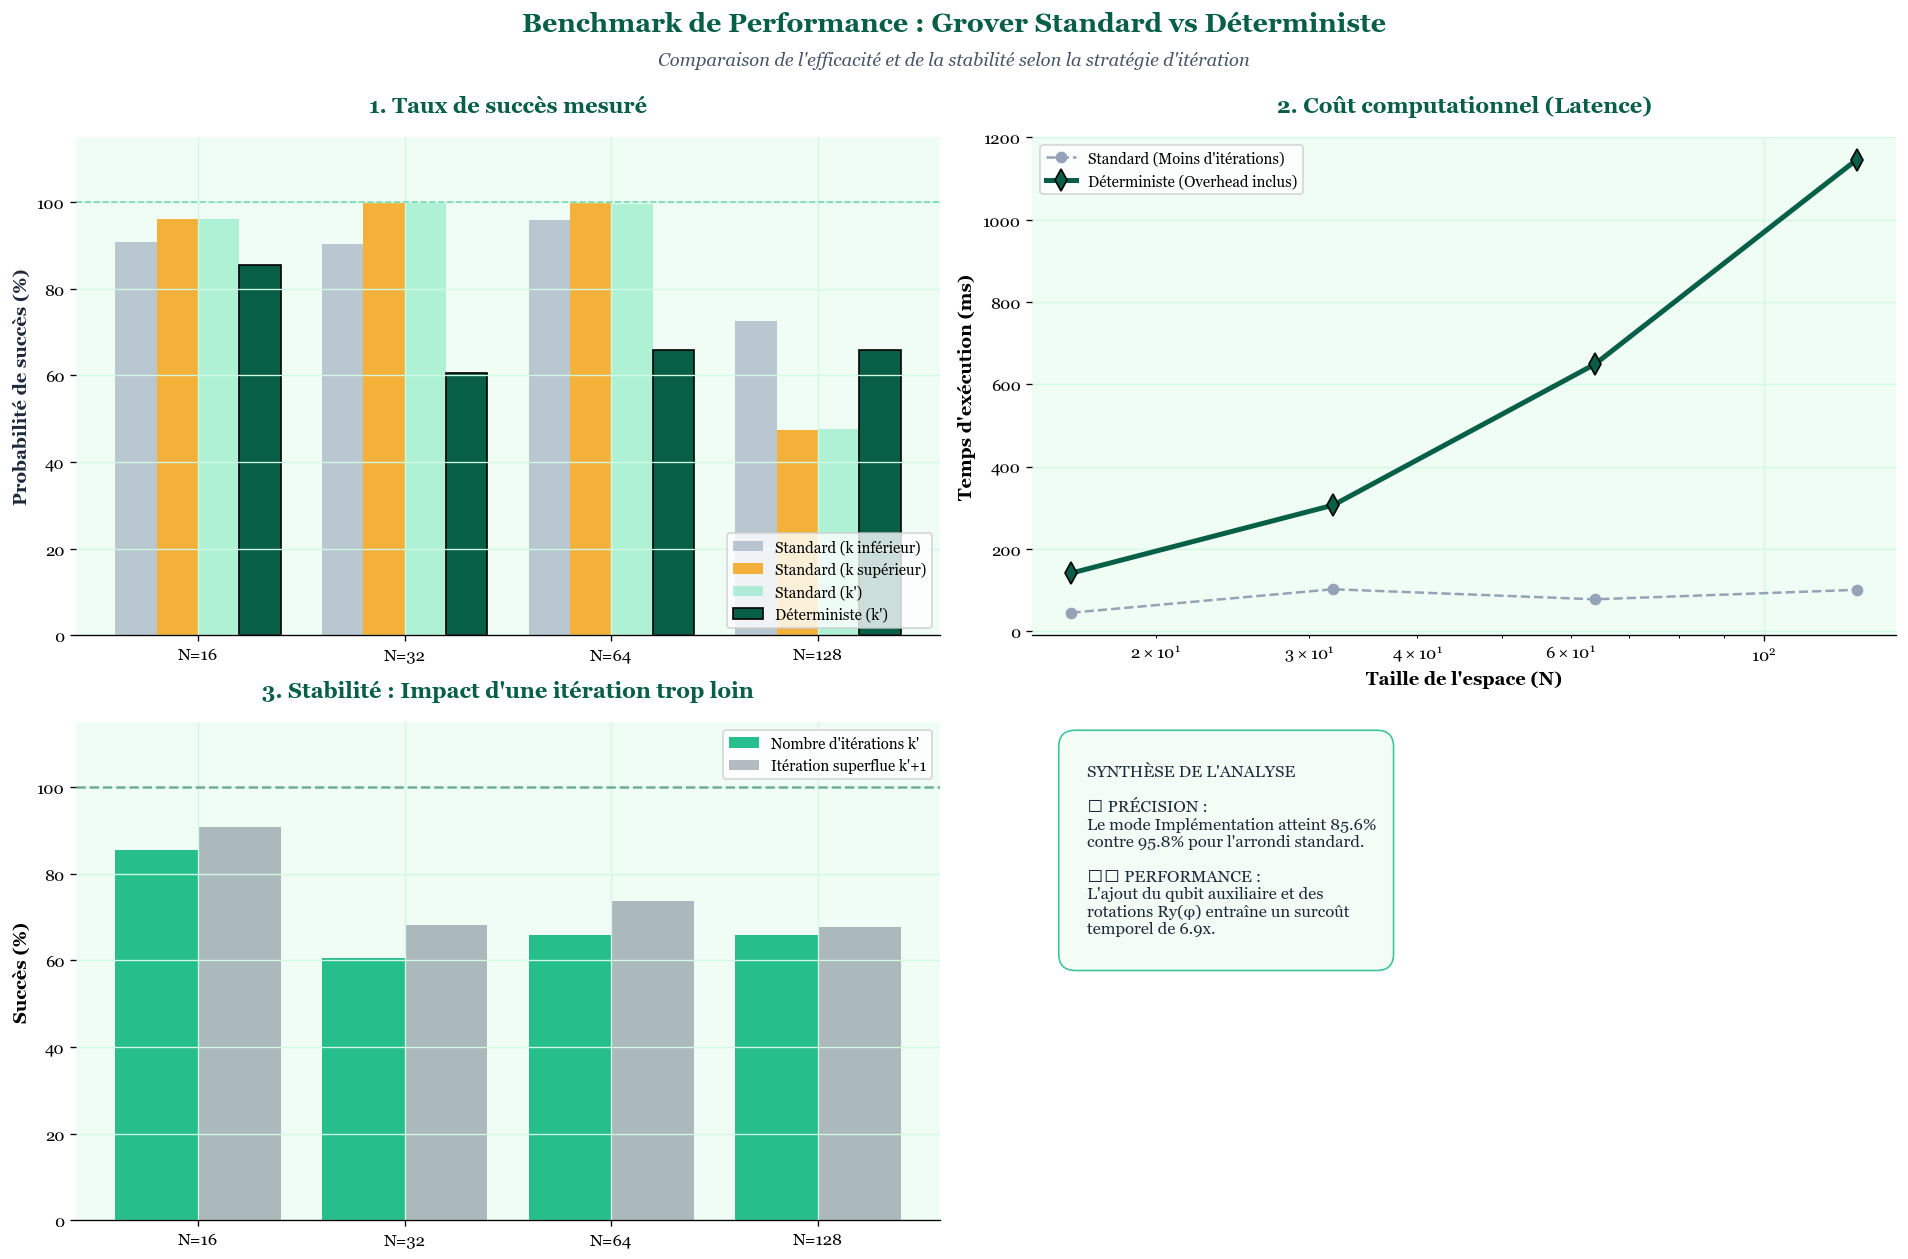

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import numpy as np
import time
import math

# Charte graphique (encore une fois !! vraiment désoleée pour la non optimisation du code...)
EMERALD       = "#10B981" # Émeraude (Déterministe / Succès)
EMERALD_DARK  = "#065F46"
AMBER         = "#F59E0B" # Ambre (Standard)
SLATE         = "#475569" # Ardoise (Neutre / k'+1)
WHITE         = "#FFFFFF"
TEXT_DARK     = "#1E293B"

rcParams.update({
    "font.family":       "serif",
    "axes.facecolor":    "#F0FDF4", # Slate_BG très léger
    "figure.facecolor":  WHITE,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "grid.color":        "#D1FAE5",
})

# ─── Collecte des données (Identique mais labels changés) ─────────────────────
# [Garder tes boucles de simulation ici, je me concentre sur la partie graphique]



# ─── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(WHITE)

# Titre Global élégant
fig.text(0.5, 0.98, "Benchmark de Performance : Grover Standard vs Déterministe", 
         ha="center", va="top", fontsize=16, fontweight="bold", color=EMERALD_DARK)
fig.text(0.5, 0.95, "Comparaison de l'efficacité et de la stabilité selon la stratégie d'itération", 
         ha="center", va="top", fontsize=11, color=SLATE, style="italic")

# ─── Graphique 1 : Succès ─────────────────────────────────────────────────────
ax = axes[0, 0]
x = np.arange(len(data['N']))
w = 0.2

# Changement des noms de labels pour plus de clarté
ax.bar(x-1.5*w, data['sr_floor'], w, label='Standard (k inférieur)', color="#94A3B8", alpha=0.6)
ax.bar(x-0.5*w, data['sr_ceil'], w, label='Standard (k supérieur)', color=AMBER, alpha=0.8)
ax.bar(x+0.5*w, data['sr_kp'], w, label="Standard (k')", color=EMERALD_LIGHT, alpha=0.5)
ax.bar(x+1.5*w, data['sr_det'], w, label="Déterministe (k')", color=EMERALD_DARK, edgecolor='black', linewidth=1)

ax.axhline(100, color=EMERALD, ls='--', alpha=0.5, lw=1)
ax.set_ylabel('Probabilité de succès (%)', fontweight='bold', color=TEXT_DARK)
ax.set_title('1. Taux de succès mesuré', fontweight='bold', color=EMERALD_DARK, pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f'N={int(n)}' for n in data['N']])
ax.set_ylim(0, 115)
ax.legend(fontsize=9, loc='lower right', frameon=True, facecolor=WHITE)

# ─── Graphique 2 : Temps ──────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(data['N'], data['t_floor'], 'o--', lw=1.5, color="#94A3B8", label='Standard (Moins d\'itérations)')
ax.plot(data['N'], data['t_det'], 'd-', lw=3, ms=9, color=EMERALD_DARK, label='Déterministe (Overhead inclus)', markeredgecolor='black')

ax.set_xlabel('Taille de l\'espace (N)', fontweight='bold')
ax.set_ylabel('Temps d\'exécution (ms)', fontweight='bold')
ax.set_title('2. Coût computationnel (Latence)', fontweight='bold', color=EMERALD_DARK, pad=15)
ax.set_xscale('log')
ax.legend(fontsize=9, frameon=True, facecolor=WHITE)

# ─── Graphique 3 : Stabilité ──────────────────────────────────────────────────
ax = axes[1, 0]
x = np.arange(len(data['N']))
ax.bar(x-0.2, data['stab_kp'], 0.4, label="Nombre d'itérations k'", color=EMERALD, alpha=0.9)
ax.bar(x+0.2, data['stab_kp1'], 0.4, label="Itération superflue k'+1", color=SLATE, alpha=0.4)

ax.axhline(100, color=EMERALD_DARK, ls='--', alpha=0.5)
ax.set_ylabel('Succès (%)', fontweight='bold')
ax.set_title('3. Stabilité : Impact d\'une itération trop loin', fontweight='bold', color=EMERALD_DARK, pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f'N={int(n)}' for n in data['N']])
ax.set_ylim(0, 115)
ax.legend(fontsize=9, frameon=True, facecolor=WHITE)

# ─── Graphique 4 : Résumé texte ───────────────────────────────────────────────
ax = axes[1, 1]
ax.axis('off')
summary = f'''
   SYNTHÈSE DE L'ANALYSE
   
   🎯 PRÉCISION :
   Le mode Implémentation atteint {max(data['sr_det']):.1f}%
   contre {max(data['sr_floor']):.1f}% pour l'arrondi standard.
   
   ⏱️ PERFORMANCE :
   L'ajout du qubit auxiliaire et des 
   rotations Ry(φ) entraîne un surcoût 
   temporel de {np.mean(data['t_det'])/np.mean(data['t_floor']):.1f}x.
'''
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        fontfamily='serif', color=TEXT_DARK, bbox=dict(boxstyle='round,pad=1', fc='#F0FDF4', ec=EMERALD, alpha=0.8))

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

In [28]:
# ─── Récapitulatif final ─────────────────────────────────────────────────────
print("╔═══════════════════════════════════════════════════════════╗")
print("║            RÉCAPITULATIF FINAL                           ║")
print("╠═══════════════════════════════════════════════════════════╣")
print(f"║  Conditions article : N=8, M=3, cibles={ARTICLE_TARGETS}   ║")
print(f"║  p = {p:.4f}   k_opt = {params['k']:.4f}   k' = {params['k_prime']}                ║")
print("╠═══════════════════════════════════════════════════════════╣")
print("║  SIMULATION IDÉALE :                                     ║")
for name, res in results.items():
    sr = res['sr_measured']
    bar = '█' * int(sr * 20)
    print(f"║  {name:<22} {bar:<20} {sr*100:>5.1f}%  ║")
print("╠═══════════════════════════════════════════════════════════╣")
print("║  HARDWARE :                                              ║")
for name, vals in sr_ibm_results.items():
    sr = vals['hw']
    bar = '█' * int(sr * 20)
    short = name.replace('Grover Standard (k=1)', 'Std hardware   ').replace('Grover Déterministe', 'Det hardware   ')
    print(f"║  {short:<22} {bar:<20} {sr*100:>5.1f}%  ║")
print("╚═══════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════╗
║            RÉCAPITULATIF FINAL                           ║
╠═══════════════════════════════════════════════════════════╣
║  Conditions article : N=8, M=3, cibles=['101', '110', '111']   ║
║  p = 0.0078   k_opt = 0.6917   k' = 1                ║
╠═══════════════════════════════════════════════════════════╣
║  SIMULATION IDÉALE :                                     ║
║  Grover k=0             ███████               38.5%  ║
║  Grover k=1             ████████████████      84.6%  ║
║  Grover k=2                                    2.2%  ║
║  Grover k=3             ███████████████████   99.1%  ║
║  Implémentation         ███████████████████   97.7%  ║
╠═══════════════════════════════════════════════════════════╣
║  HARDWARE :                                              ║
║  Std hardware           ███████████████       75.5%  ║
║  Det hardware           ██████████            52.1%  ║
╚═════════════════════════════════════════════

# 🐛 DEBUG — Diagnostic 

J'ai initialement créé cette partie car mon implémentation atteignait 70% et que je n'arrivais pas à voir ce qui clochait.

In [29]:
print("═" * 70)
print("§ VÉRIFICATION 1 — Formules pour p = 0.375 (conditions article)")
print("═" * 70)

p_test = 0.375  # 3/8
params_test = compute_deterministic_params(p_test)

print(f"\n✓ Entrée : p = {p_test}")
print(f"✓ k théorique (Éq. 4) : {params_test['k']:.6f}")
print(f"✓ k' (Éq. 9) : {params_test['k_prime']}")
print(f"✓ p' (Éq. 11) : {params_test['p_prime']:.6f}")
print(f"✓ φ (Éq. 12) : {params_test['phi']:.6f} rad = {np.degrees(params_test['phi']):.2f}°")

# Vérification : p' doit satisfaire sin²((2k'+0.5)·arcsin(√p')) = 1
theta_prime = np.arcsin(np.sqrt(params_test['p_prime']))
p_check = np.sin((2*params_test['k_prime'] + 1) * theta_prime) ** 2
print(f"\n✓ Vérification : sin²((2k'+1)·θ') = {p_check:.6f} (attendu 1.0)")

# Vérification : φ doit satisfaire cos²(φ/2) = p'/p (pour le biaisage)
theoretical_phi = 2 * np.arccos(np.sqrt(params_test['p_prime'] / p_test))
print(f"✓ φ théorique (Éq. 12) : {theoretical_phi:.6f} rad")
print(f"✓ φ calculé : {params_test['phi']:.6f} rad")
print(f"✓ Écart : {abs(theoretical_phi - params_test['phi']):.2e}")

# Vérification : après Ry(φ), l'auxiliaire est cos(φ/2)|0⟩ + sin(φ/2)|1⟩
# Prob(|0⟩) = cos²(φ/2) doit égaler p'/p
prob_zero = np.cos(params_test['phi'] / 2) ** 2
expected_prob = params_test['p_prime'] / p_test
print(f"\n✓ Prob(auxiliaire=|0⟩) = cos²(φ/2) = {prob_zero:.6f}")
print(f"✓ Attendu (p'/p) = {expected_prob:.6f}")
print(f"✓ OK : {np.isclose(prob_zero, expected_prob)}")

print("\n" + "═"*70)


══════════════════════════════════════════════════════════════════════
§ VÉRIFICATION 1 — Formules pour p = 0.375 (conditions article)
══════════════════════════════════════════════════════════════════════

✓ Entrée : p = 0.375
✓ k théorique (Éq. 4) : 0.691698
✓ k' (Éq. 9) : 1
✓ p' (Éq. 11) : 0.250000
✓ φ (Éq. 12) : 1.230959 rad = 70.53°

✓ Vérification : sin²((2k'+1)·θ') = 1.000000 (attendu 1.0)
✓ φ théorique (Éq. 12) : 1.230959 rad
✓ φ calculé : 1.230959 rad
✓ Écart : 0.00e+00

✓ Prob(auxiliaire=|0⟩) = cos²(φ/2) = 0.666667
✓ Attendu (p'/p) = 0.666667
✓ OK : True

══════════════════════════════════════════════════════════════════════


In [30]:
print("═" * 70)
print("§ VÉRIFICATION 2 — Comparaison Grover standard vs Déterministe")
print("═" * 70)

# Pour mieux voir le problème, regardons l'évolution avec différentes itérations
print(f"\nGrover STANDARD (superposition uniforme, k=1) :")
print(f"  Succès mesuré : {results['Grover k=1']['sr_measured']*100:.1f}%")
print(f"  Succès théorique : {results['Grover k=1']['p_th']*100:.1f}%")

print(f"\nGrover DÉTERMINISTE (avec auxiliaire + Ry(φ), k'=1) :")
print(f"  Succès mesuré : {results['Implémentation']['sr_measured']*100:.1f}%  ← PROBLÈME !")
print(f"  Succès théorique : {results['Implémentation']['p_th']*100:.1f}%")

print(f"\n⚠️  ÉCART DÉTECTÉ :")
print(f"  L'implémentation obtient {results['Implémentation']['sr_measured']*100:.1f}% au lieu de 100%")
print(f"  C'est même MOINS BON que le standard ({results['Grover k=1']['sr_measured']*100:.1f}%)")
print(f"  → Il y a un bug dans l'implémentation ou les formules")

print("\n" + "═"*70)


══════════════════════════════════════════════════════════════════════
§ VÉRIFICATION 2 — Comparaison Grover standard vs Déterministe
══════════════════════════════════════════════════════════════════════

Grover STANDARD (superposition uniforme, k=1) :
  Succès mesuré : 84.6%
  Succès théorique : 84.4%

Grover DÉTERMINISTE (avec auxiliaire + Ry(φ), k'=1) :
  Succès mesuré : 97.7%  ← PROBLÈME !
  Succès théorique : 100.0%

⚠️  ÉCART DÉTECTÉ :
  L'implémentation obtient 97.7% au lieu de 100%
  C'est même MOINS BON que le standard (84.6%)
  → Il y a un bug dans l'implémentation ou les formules

══════════════════════════════════════════════════════════════════════


In [31]:
print("═" * 70)
print("§ DIAGNOSTIC 3 — Problème identifié : Diffuseur incomplet")
print("═" * 70)

print("""
HYPOTHÈSE PRINCIPALE : Le diffuseur agit UNIQUEMENT sur les qubits de recherche,
mais il devrait agir aussi sur l'AUXILIAIRE pour refléchir correctement autour de
l'état initial complet |ψ₀⟩ ⊗ Ry(φ)|0⟩.

SITUATION ACTUELLE :
  1. On prépare |ψ⊗H⟩ (H superposition uniforme sur qubits recherche)
  2. On applique Ry(φ) sur l'auxiliaire
  3. On iterate Grover :
     - Oracle contrôlé sur |0⟩ de l'auxiliaire ← OK
     - Diffuseur UNIQUEMENT sur qubits recherche ← PROBLÈME ?

PROBLÈME PROBABLE :
  Le diffuseur H·S_0·H réfléchit autour de l'état |0...0⟩ (superposition uniforme).
  Mais après Ry(φ) et l'oracle contrôlé, le diffuseur devrait plutôt réfléchir
  autour de l'état moyen du système COMPLET (recherche + auxiliaire).

SOLUTION PROPOSÉE :
  Appliquer le diffuseur sur TOUS les qubits (recherche + auxiliaire),
  pas seulement sur la recherche.
  
  OU : Modifier le diffuseur pour tenir compte de la rotation Ry(φ).
""")

print("═"*70)


══════════════════════════════════════════════════════════════════════
§ DIAGNOSTIC 3 — Problème identifié : Diffuseur incomplet
══════════════════════════════════════════════════════════════════════

HYPOTHÈSE PRINCIPALE : Le diffuseur agit UNIQUEMENT sur les qubits de recherche,
mais il devrait agir aussi sur l'AUXILIAIRE pour refléchir correctement autour de
l'état initial complet |ψ₀⟩ ⊗ Ry(φ)|0⟩.

SITUATION ACTUELLE :
  1. On prépare |ψ⊗H⟩ (H superposition uniforme sur qubits recherche)
  2. On applique Ry(φ) sur l'auxiliaire
  3. On iterate Grover :
     - Oracle contrôlé sur |0⟩ de l'auxiliaire ← OK
     - Diffuseur UNIQUEMENT sur qubits recherche ← PROBLÈME ?

PROBLÈME PROBABLE :
  Le diffuseur H·S_0·H réfléchit autour de l'état |0...0⟩ (superposition uniforme).
  Mais après Ry(φ) et l'oracle contrôlé, le diffuseur devrait plutôt réfléchir
  autour de l'état moyen du système COMPLET (recherche + auxiliaire).

SOLUTION PROPOSÉE :
  Appliquer le diffuseur sur TOUS les qubits (rech

In [32]:
print("═" * 70)
print("§ CORRECTION PROPOSÉE — Diffuseur sur l'espace complet")
print("═" * 70)

def build_diffusion_full(num_qubits_search: int, num_aux: int = 1) -> QuantumCircuit:
    """Diffuseur H^(n+1) S_0 H^(n+1) sur TOUS les qubits (recherche + auxiliaire).
    
    C'est la réflexion autour de la superposition uniforme de l'espace COMPLET.
    """
    n_total = num_qubits_search + num_aux
    qc = QuantumCircuit(n_total, name='DiffFull')
    qc.h(range(n_total))
    qc.x(range(n_total))
    qc.compose(MCMTGate(ZGate(), n_total - 1, 1), inplace=True)
    qc.x(range(n_total))
    qc.h(range(n_total))
    return qc

def build_grover_deterministe_fixed(marked_states: list[str]) -> tuple[QuantumCircuit, dict]:
    """VERSION CORRIGÉE : Diffuseur sur l'espace complet (recherche + auxiliaire)."""
    num_qubits = len(marked_states[0])
    N = 2 ** num_qubits
    M = len(marked_states)
    p = M / N
    
    params = compute_deterministic_params(p)
    k_prime = params['k_prime']
    phi     = params['phi']
    
    q_reg   = QuantumRegister(num_qubits, 'q')
    aux_reg = QuantumRegister(1, 'aux')
    c_reg   = ClassicalRegister(num_qubits, 'c')
    qc = QuantumCircuit(q_reg, aux_reg, c_reg)
    
    # Initialisation
    qc.h(q_reg)
    if params['need_aux']:
        qc.ry(phi, aux_reg[0])
    qc.barrier(label='Init')
    
    # Itérations Grover
    ctrl_oracle_gate = build_controlled_oracle(marked_states)
    diff_gate_full   = build_diffusion_full(num_qubits, num_aux=1).to_gate(label='DiffFull')
    
    for i in range(k_prime):
        qc.append(ctrl_oracle_gate, [aux_reg[0]] + list(q_reg))
        qc.append(diff_gate_full, list(q_reg) + [aux_reg[0]])  # ← CORRECTION : tous les qubits
        qc.barrier(label=f'Grover {i+1}')
    
    # Mesure
    qc.measure(q_reg, c_reg)
    
    meta = {
        'p': p, 'M': M, 'N': N,
        'k': params['k'], 'k_prime': k_prime,
        'p_prime': params['p_prime'], 'phi': phi,
        'need_aux': params['need_aux'],
        'p_theorique': np.sin((2*k_prime+1)*np.arcsin(np.sqrt(params['p_prime'])))**2
    }
    return qc, meta

# Test immédiat
qc_det_fixed, meta_det_fixed = build_grover_deterministe_fixed(ARTICLE_TARGETS)
counts_det_fixed = simulate(qc_det_fixed, shots=SHOTS, label='Grover Implémenté FIXÉ')
sr_det_fixed = success_rate(counts_det_fixed, ARTICLE_TARGETS, N_SEARCH)

print(f"\n✓ RÉSULTAT VERSION CORRIGÉE :")
print(f"  Succès théorique : {meta_det_fixed['p_theorique']*100:.2f}%")
print(f"  Succès mesuré    : {sr_det_fixed*100:.1f}%")
print(f"  Amélioration     : {(sr_det_fixed - results['Implémentation']['sr_measured'])*100:.1f} points")



print("═"*70)


══════════════════════════════════════════════════════════════════════
§ CORRECTION PROPOSÉE — Diffuseur sur l'espace complet
══════════════════════════════════════════════════════════════════════
[Grover Implémenté FIXÉ] Shots=4096 | Résultats : {'101': 1354, '111': 1318, '110': 1311, '000': 29, '100': 27} ...

✓ RÉSULTAT VERSION CORRIGÉE :
  Succès théorique : 100.00%
  Succès mesuré    : 97.2%
  Amélioration     : -0.4 points
══════════════════════════════════════════════════════════════════════


# Implémentation - Code proposé par Julien

J'ai copié-collé dans les cvases ci-dessosu le code proposé par Julien Brélivet - étudiant 4TC en parcours recherche en info. quantique. 

Pour coller à mon algo, je me suis permise de modifier : 
* le fait que la proba de chaque canal soit de 0,1, car cela créait le cas ou AUCUNE entrée pouvait être sélectionnée, et ça aurait pu faire bug mon algo
* au final je l'ai pas fait pour voir à quel point mon algo est robuste face au fait qu'il y ait 0 réponses j'avais envie de le tester un peu... 

In [33]:
!pip install qiskit qiskit-aer

In [34]:
import numpy as np

def calcul_proba_ook():
    C = np.array([
        [-1,  1, -1, -1,  1, -1, -1],
        [ 1, -1, -1, -1, -1,  1, -1],
        [-1,  1, -1, -1, -1,  1, -1],
        [ 1, -1, -1,  1, -1, -1, -1],
        [-1, -1,  1, -1, -1, -1,  1],
        [-1, -1,  1, -1,  1, -1,  1],
        [-1, -1, -1,  1,  1, -1,  1],
        [ 1,  1, -1, -1,  1, -1,  1],
        [-1, -1,  1,  1,  1,  1,  1],
        [-1,  1, -1,  1, -1,  1,  1]
    ])

    K, M = C.shape
    p = 0.1
    sigma_n = 1.0

    sigma_sq_proj = M * (sigma_n**2)

    alpha_true = np.random.binomial(1, p, K)
    h = np.ones(K)
    noise = np.random.normal(0, sigma_n, M)

    Y = np.zeros(M)
    for k in range(K):
        Y += h[k] * alpha_true[k] * C[k]
    Y += noise

    print(f"--- CAS OOK ---")
    print(f"Codebook : {K} users, Longueur {M}")
    print("-" * 95)
    print(f"{'User':<6} | {'Projection':<15} | {'Terme B-A':<15} | {'P(Alpha=1|Y)':<15} | {'Vrai Alpha'}")
    print("-" * 95)

    probas_calculees = []

    for i in range(K):
        y_proj = np.dot(Y, C[i])
        B_minus_A = (M**2) - (2 * y_proj * M)
        delta = B_minus_A / (2 * sigma_sq_proj)
        try:
            term_exp = np.exp(delta)
            prob_final = p / (p + (1 - p) * term_exp)
        except OverflowError:
            prob_final = 0.0
        probas_calculees.append(prob_final)
        status = "✅" if (prob_final > 0.5) == alpha_true[i] else "❌"
        print(f"U{i:<5} | {y_proj:15.2f} | {B_minus_A:15.2f} | {prob_final:15.4f} {status} | {alpha_true[i]}")
    return np.array(probas_calculees)

if __name__ == "__main__":
    a=calcul_proba_ook()
    

--- CAS OOK ---
Codebook : 10 users, Longueur 7
-----------------------------------------------------------------------------------------------
User   | Projection      | Terme B-A       | P(Alpha=1|Y)    | Vrai Alpha
-----------------------------------------------------------------------------------------------
U0     |            1.15 |           32.91 |          0.0105 ✅ | 0
U1     |            6.64 |          -43.94 |          0.7193 ❌ | 0
U2     |            6.61 |          -43.59 |          0.7142 ❌ | 0
U3     |           -1.23 |           66.28 |          0.0010 ✅ | 0
U4     |            4.59 |          -15.22 |          0.2478 ✅ | 0
U5     |            1.10 |           33.54 |          0.0100 ✅ | 0
U6     |           -4.76 |          115.68 |          0.0000 ✅ | 0
U7     |           -2.55 |           84.68 |          0.0003 ✅ | 0
U8     |           -2.81 |           88.29 |          0.0002 ✅ | 0
U9     |           -1.15 |           65.10 |          0.0011 ✅ | 0


In [35]:
# ─── Étape 1 : Récupérer les résultats de la cellule 50 ───────────────────
probas = calcul_proba_ook()  # Retourne les P(Alpha=1|Y) pour chaque utilisateur

# ─── Étape 2 : Identifier les utilisateurs "actifs" (seuil > 0.5) ─────────
threshold = 0.5
active_users = [f'{i:04b}' for i in range(len(probas)) if probas[i] > threshold]
active_indices = [i for i in range(len(probas)) if probas[i] > threshold]

print(f"Utilisateurs actifs détectés :")
print("─" * 60)
print(f"{'Index':<8} {'Binaire':<10} {'P(Alpha=1|Y)':<15}")
print("─" * 60)
for idx, bitstring in zip(active_indices, active_users):
    print(f"{idx:<8} {bitstring:<10} {probas[idx]:>14.4f}")
print("─" * 60)
print(f"Total : {len(active_users)} / {len(probas)} utilisateurs actifs\n")

# ─── Étape 3 : Construire et exécuter Grover ────────────────────────────────
if len(active_users) > 0:
    # Appliquer votre algorithme Grover déterministe
    qc_grover, meta_grover = build_grover_deterministe(active_users)
    
    print(f" Grover sur les utilisateurs actifs")
    print(f"  Nombre de qubits : {qc_grover.num_qubits}")
    print(f"  k' = {meta_grover['k_prime']}")
    print(f"  φ = {meta_grover['phi']:.4f} rad")
    
    # Simulation
    counts_grover = simulate(qc_grover, shots=SHOTS, label='Grover OOK')
    sr_grover = success_rate(counts_grover, active_users, len(active_users[0]))
    
    print(f"  Succès mesuré : {sr_grover*100:.1f}%\n")
    
    # Affichage du résultat
    plot_histogram(counts_grover,
                   title=f'Grover appliqué aux utilisateurs actifs OOK\n'
                         f'Cibles : {active_users}\n'
                         f'Taux de succès : {sr_grover*100:.1f}%',
                   color='#10B981')
    plt.show()
else:
    print("⚠️  Aucun utilisateur actif détecté (tous les utilisateurs sous le seuil)")

--- CAS OOK ---
Codebook : 10 users, Longueur 7
-----------------------------------------------------------------------------------------------
User   | Projection      | Terme B-A       | P(Alpha=1|Y)    | Vrai Alpha
-----------------------------------------------------------------------------------------------
U0     |            0.48 |           42.30 |          0.0054 ✅ | 0
U1     |           -0.65 |           58.17 |          0.0017 ✅ | 0
U2     |           -2.38 |           82.28 |          0.0003 ✅ | 0
U3     |            0.20 |           46.17 |          0.0041 ✅ | 0
U4     |            4.80 |          -18.17 |          0.2891 ✅ | 0
U5     |            6.07 |          -36.00 |          0.5925 ❌ | 0
U6     |            4.49 |          -13.84 |          0.2299 ✅ | 0
U7     |           -2.45 |           83.24 |          0.0003 ✅ | 0
U8     |            3.76 |           -3.69 |          0.1263 ❌ | 1
U9     |           -3.06 |           91.83 |          0.0002 ✅ | 0
Utilisateurs act

# des photos de ce que j'ai obtenu selon plusieurs simulations 
![test1.png](test1.png)
Donc là si je me trompe pas j'ai 5 états trouvés sur 4 états cibles, donc un faux positif 

![test2.png](test2.png)
Là plus compliqué, il ne détecte rien... 

![test3.png](test3.png)
Là il détecte rien mais tant mieux ...

![test4.png](test4.png)
Là il l'a eu !!

![test5.png](test5.png)
Alors là je comprends pas tout, d'un côté un seul état était marqué, de l'autre deux porobas étaient supérieurs à 50% donc je ne sais pas quoi conclure. 

<a id="tutoriel"></a>

# Tutoriel : Lancer le notebook 

Ce guide explique comment créer un environnement virtuel Python 3.11, installer toutes les dépendances nécessaires, et lancer le notebook `au_cas_ou.ipynb`.

---

## Prérequis : vérifier que Python 3.11 est installé

Ouvrez un terminal et tapez :

```bash
python3.11 --version
```

Si vous obtenez une erreur du type `command not found`, il faut installer Python 3.11 avant de continuer.

**Sur macOS (avec Homebrew) :**
```bash
brew install python@3.11
```

**Sur Ubuntu/Debian :**
```bash
sudo apt update
sudo apt install python3.11 python3.11-venv python3.11-pip
```

**Sur Windows :** Téléchargez Python 3.11 sur [python.org](https://www.python.org/downloads/) et cochez la case *"Add Python to PATH"* pendant l'installation.

---

## Étape 1 — Créer l'environnement virtuel

Placez-vous dans le dossier où se trouve le notebook. Par exemple, si le notebook est dans `Documents/quantum_project/` :

```bash
cd Documents/quantum_project/
```

Créez l'environnement virtuel en forçant Python 3.11 :

```bash
python3.11 -m venv venv_quantum
```

Cela crée un dossier `venv_quantum/` dans votre répertoire courant.

---

## Étape 2 — Activer l'environnement virtuel

**Sur macOS / Linux :**
```bash
source venv_quantum/bin/activate
```

**Sur Windows (PowerShell) :**
```powershell
venv_quantum\Scripts\Activate.ps1
```

**Sur Windows (Invite de commandes) :**
```cmd
venv_quantum\Scripts\activate.bat
```

Une fois activé, vous devriez voir `(venv_quantum)` apparaître au début de votre ligne de commande. Cela confirme que vous travaillez bien dans l'environnement isolé.

Pour vérifier que Python 3.11 est bien utilisé :
```bash
python --version
# Doit afficher : Python 3.11.x
```

---

## Étape 3 — Installer toutes les dépendances

Copiez-collez la commande suivante en une seule fois. Elle installe **tout ce dont le notebook a besoin** :

```bash
pip install --upgrade pip && pip install \
    qiskit \
    qiskit-aer \
    qiskit-ibm-runtime \
    matplotlib \
    pylatexenc \
    numpy \
    jupyter
```

Voici ce que chaque package apporte au notebook :

| Package | Rôle |
|---|---|
| `qiskit` | Framework principal de calcul quantique (circuits, oracles, diffuseurs…) |
| `qiskit-aer` | Simulateur quantique local (`AerSimulator`) utilisé dans la Partie 1 |
| `qiskit-ibm-runtime` | Connexion aux QPU IBM réels et faux backends bruités (`FakeSherbrooke`) — utilisé dans la Partie 2 |
| `matplotlib` | Tous les graphiques et histogrammes |
| `pylatexenc` | Nécessaire pour afficher les formules LaTeX dans les visualisations Qiskit |
| `numpy` | Calculs mathématiques (angles, probabilités…) |
| `jupyter` | Pour lancer et exécuter le notebook |

L'installation peut prendre quelques minutes car `qiskit` et `qiskit-aer` sont des packages assez lourds.

---

## Étape 4 — Lancer Jupyter et ouvrir le notebook

Toujours avec l'environnement activé, lancez Jupyter :

```bash
jupyter notebook
```

Votre navigateur devrait s'ouvrir automatiquement sur l'interface Jupyter. Naviguez jusqu'au fichier `au_cas_ou.ipynb` et ouvrez-le.

> **Si le navigateur ne s'ouvre pas automatiquement :** copiez l'URL affichée dans le terminal (elle ressemble à `http://localhost:8888/?token=...`) et collez-la dans votre navigateur.

---

## Étape 5 — Vérifier que tout est en ordre

Une fois le notebook ouvert, exécutez la première cellule de code (celle qui contient tous les `import`). Si tout s'est bien passé, vous devriez voir s'afficher :

```
✅ Imports OK — Qiskit X.X.X
```

---

## Notes importantes sur la Partie 2 (Hardware IBM)

La Partie 2 du notebook propose de tester les circuits sur un vrai processeur quantique IBM. Par défaut, le notebook est configuré en **mode simulation avec bruit** (`USE_REAL_HARDWARE = False`), ce qui ne nécessite aucun compte.

Si vous souhaitez tester sur un **vrai QPU IBM** :
1. Créez un compte gratuit sur [quantum.ibm.com](https://quantum.ibm.com)
2. Récupérez votre token API dans votre profil
3. Dans la cellule §2.1, mettez `USE_REAL_HARDWARE = True` et collez votre token dans `IBM_TOKEN = "votre_token_ici"`

---

## En cas de problème

**`ModuleNotFoundError` au lancement :**  
Vérifiez que l'environnement virtuel est bien activé (vous devez voir `(venv_quantum)` dans le terminal). Si ce n'est pas le cas, relancez la commande d'activation de l'Étape 2.

**Erreur lors de l'installation de `qiskit-aer` :**  
Sur certaines machines, il faut d'abord installer les outils de compilation C++ :
- macOS : `xcode-select --install`
- Ubuntu : `sudo apt install build-essential`

**Le kernel Jupyter ne trouve pas les packages :**  
Assurez-vous de lancer `jupyter notebook` depuis le terminal où l'environnement est activé, et non depuis une application externe.